<a href="https://colab.research.google.com/github/formacionCDIA/cursoCDIA/blob/main/Notebooks/6_Modelos_Regresion_Avanzado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Análisis de datos y aprendizaje automático**
---
# **6.Modelos de Regresión**


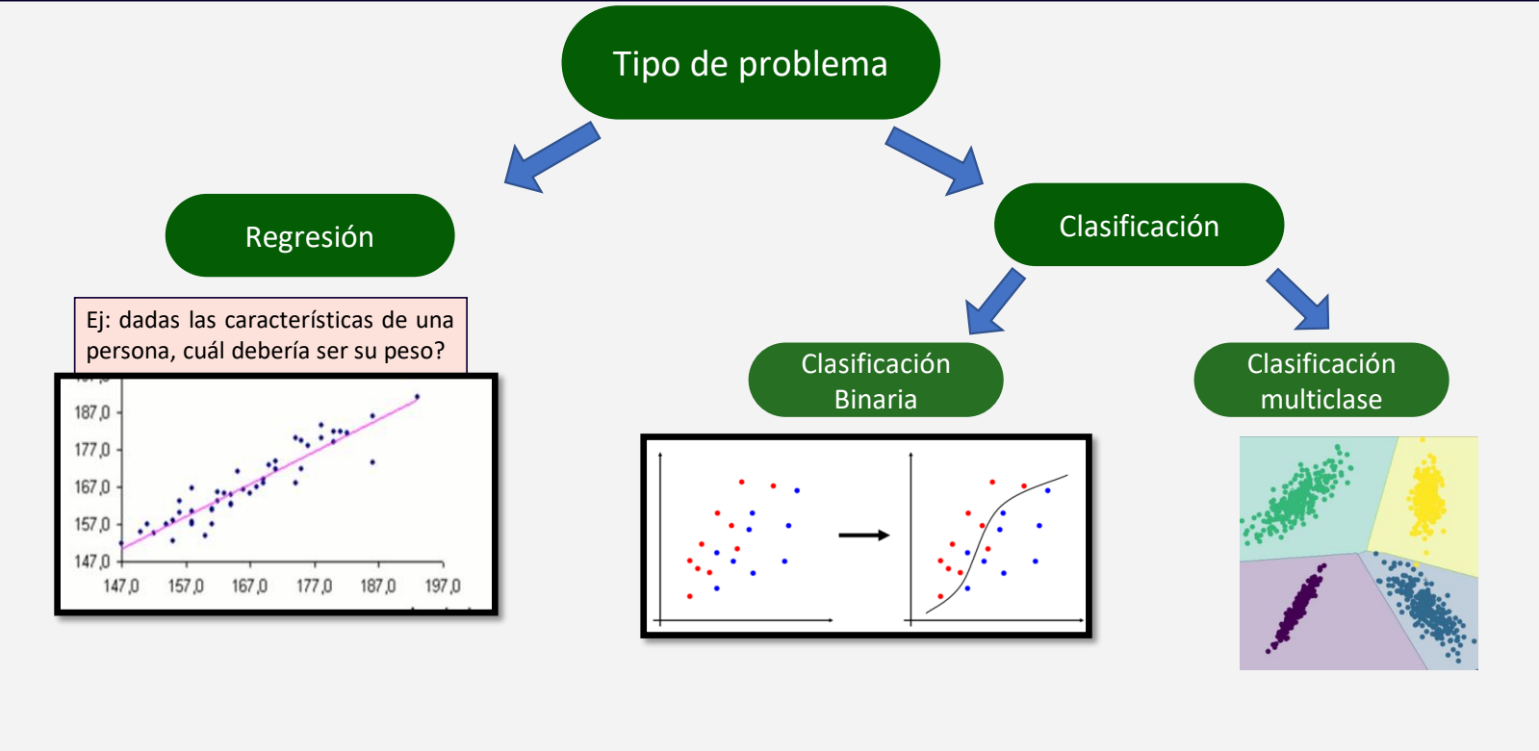

### Objetivos

Predecir una variable numérica.

Ejemplos:
- Precio de una casa
- Precio de acciones
- Nota de un examen

Consiste en predecir un valor numérico "y" en base a los atributos "X" (x1, x2, x3, ..., xn).

Un *modelo de regresión* proporciona una función que describe la relación entre una o más variables independientes y una variable respuesta, dependiente u objetivo.

Por ejemplo, la relación entre la altura y el peso puede describirse mediante un modelo de regresión lineal. Un análisis de regresión es la base de la predicción y estudio de los efectos sobre las variables objetivo.

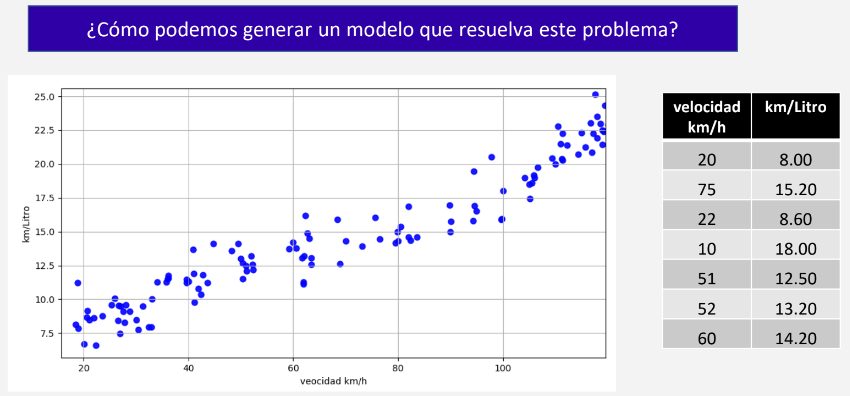

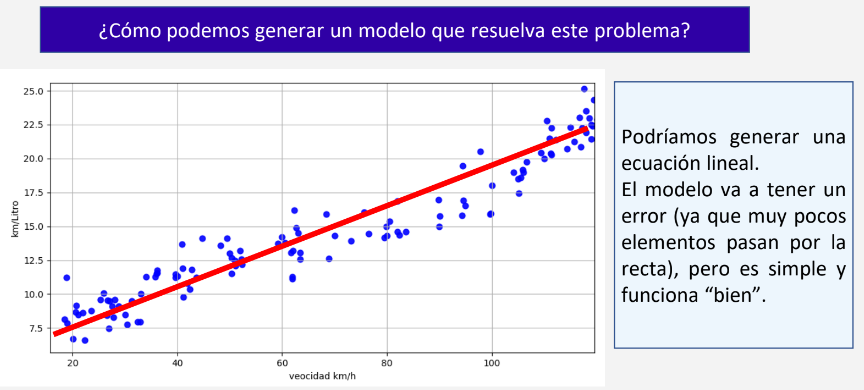

### Importamos bibliotecas necesarias

In [1]:
# from sklearn.datasets import load_boston
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Datos



Ejecute la siguiente celda para cargar el archivo CSV de los datos de casas en dataframe de **Pandas**:

**Contexto**

Este es el conjunto de datos utilizado en libro de Aurélien Géron, "Aprendizaje automático práctico con Scikit-Learn y TensorFlow". Sirve como una excelente introducción a la implementación de algoritmos de aprendizaje automático, ya que requiere una limpieza de datos rudimentaria, tiene una lista de variables fácil de entender y su tamaño óptimo es ideal.
Los datos contienen información del censo de California, Estados Unidos, de 1990.


**Objetivo del modelo**

Predecir los precios medios de las viviendas en los distritos de California derivados del censo de 1990.


**Diccionario de datos**

Los datos corresponden a las viviendas de un distrito de California y a un resumen estadístico basado en el censo de 1990 que tiene en cuenta la casa dentro de una manzana. Tenga en cuenta que los datos no están depurados, por lo que requieren preprocesamiento. Las columnas son las siguientes:

* **longitude (longitud)**: Indica la distancia al oeste de una casa; un valor más alto indica que está más al oeste.

* **latitude (latitud)**: Indica la distancia al norte de una casa; un valor más alto indica que está más al norte.

* **housing_median_age (edad mediana de la Vivienda)**: Edad mediana de una casa dentro de una manzana; un valor más bajo indica una construcción más nueva.
* **total_rooms (habitaciones Totales)**: Número total de habitaciones dentro de una manzana.

* **total_bedrooms(dormitorios Totales)**: Número total de dormitorios dentro de una manzana.

* **population (población)**: Número total de personas que residen en una manzana.

* **households (hogares)**: Número total de hogares, un grupo de personas que residen dentro de una unidad de vivienda, para una manzana.

* **median_income (ingresos medianos)**: Ingresos mediano de los hogares dentro de una manzana de casas (medidos en decenas de miles de dólares estadounidenses).

* **median_house_value (valor mediano de la casa)**: Valor mediano de la casa para los hogares dentro de una manzana (medido en dólares estadounidenses).

* **ocean_proximity (proximidad al Océano)**: Ubicación de la casa con respecto al océano/mar.

[Informacion del conjunto de datos](https://www.kaggle.com/datasets/camnugent/california-housing-prices)


In [2]:
url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'housing.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

df = pd.read_csv(ruta_archivo)

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object


In [6]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [7]:
df.shape

(20640, 10)

In [8]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


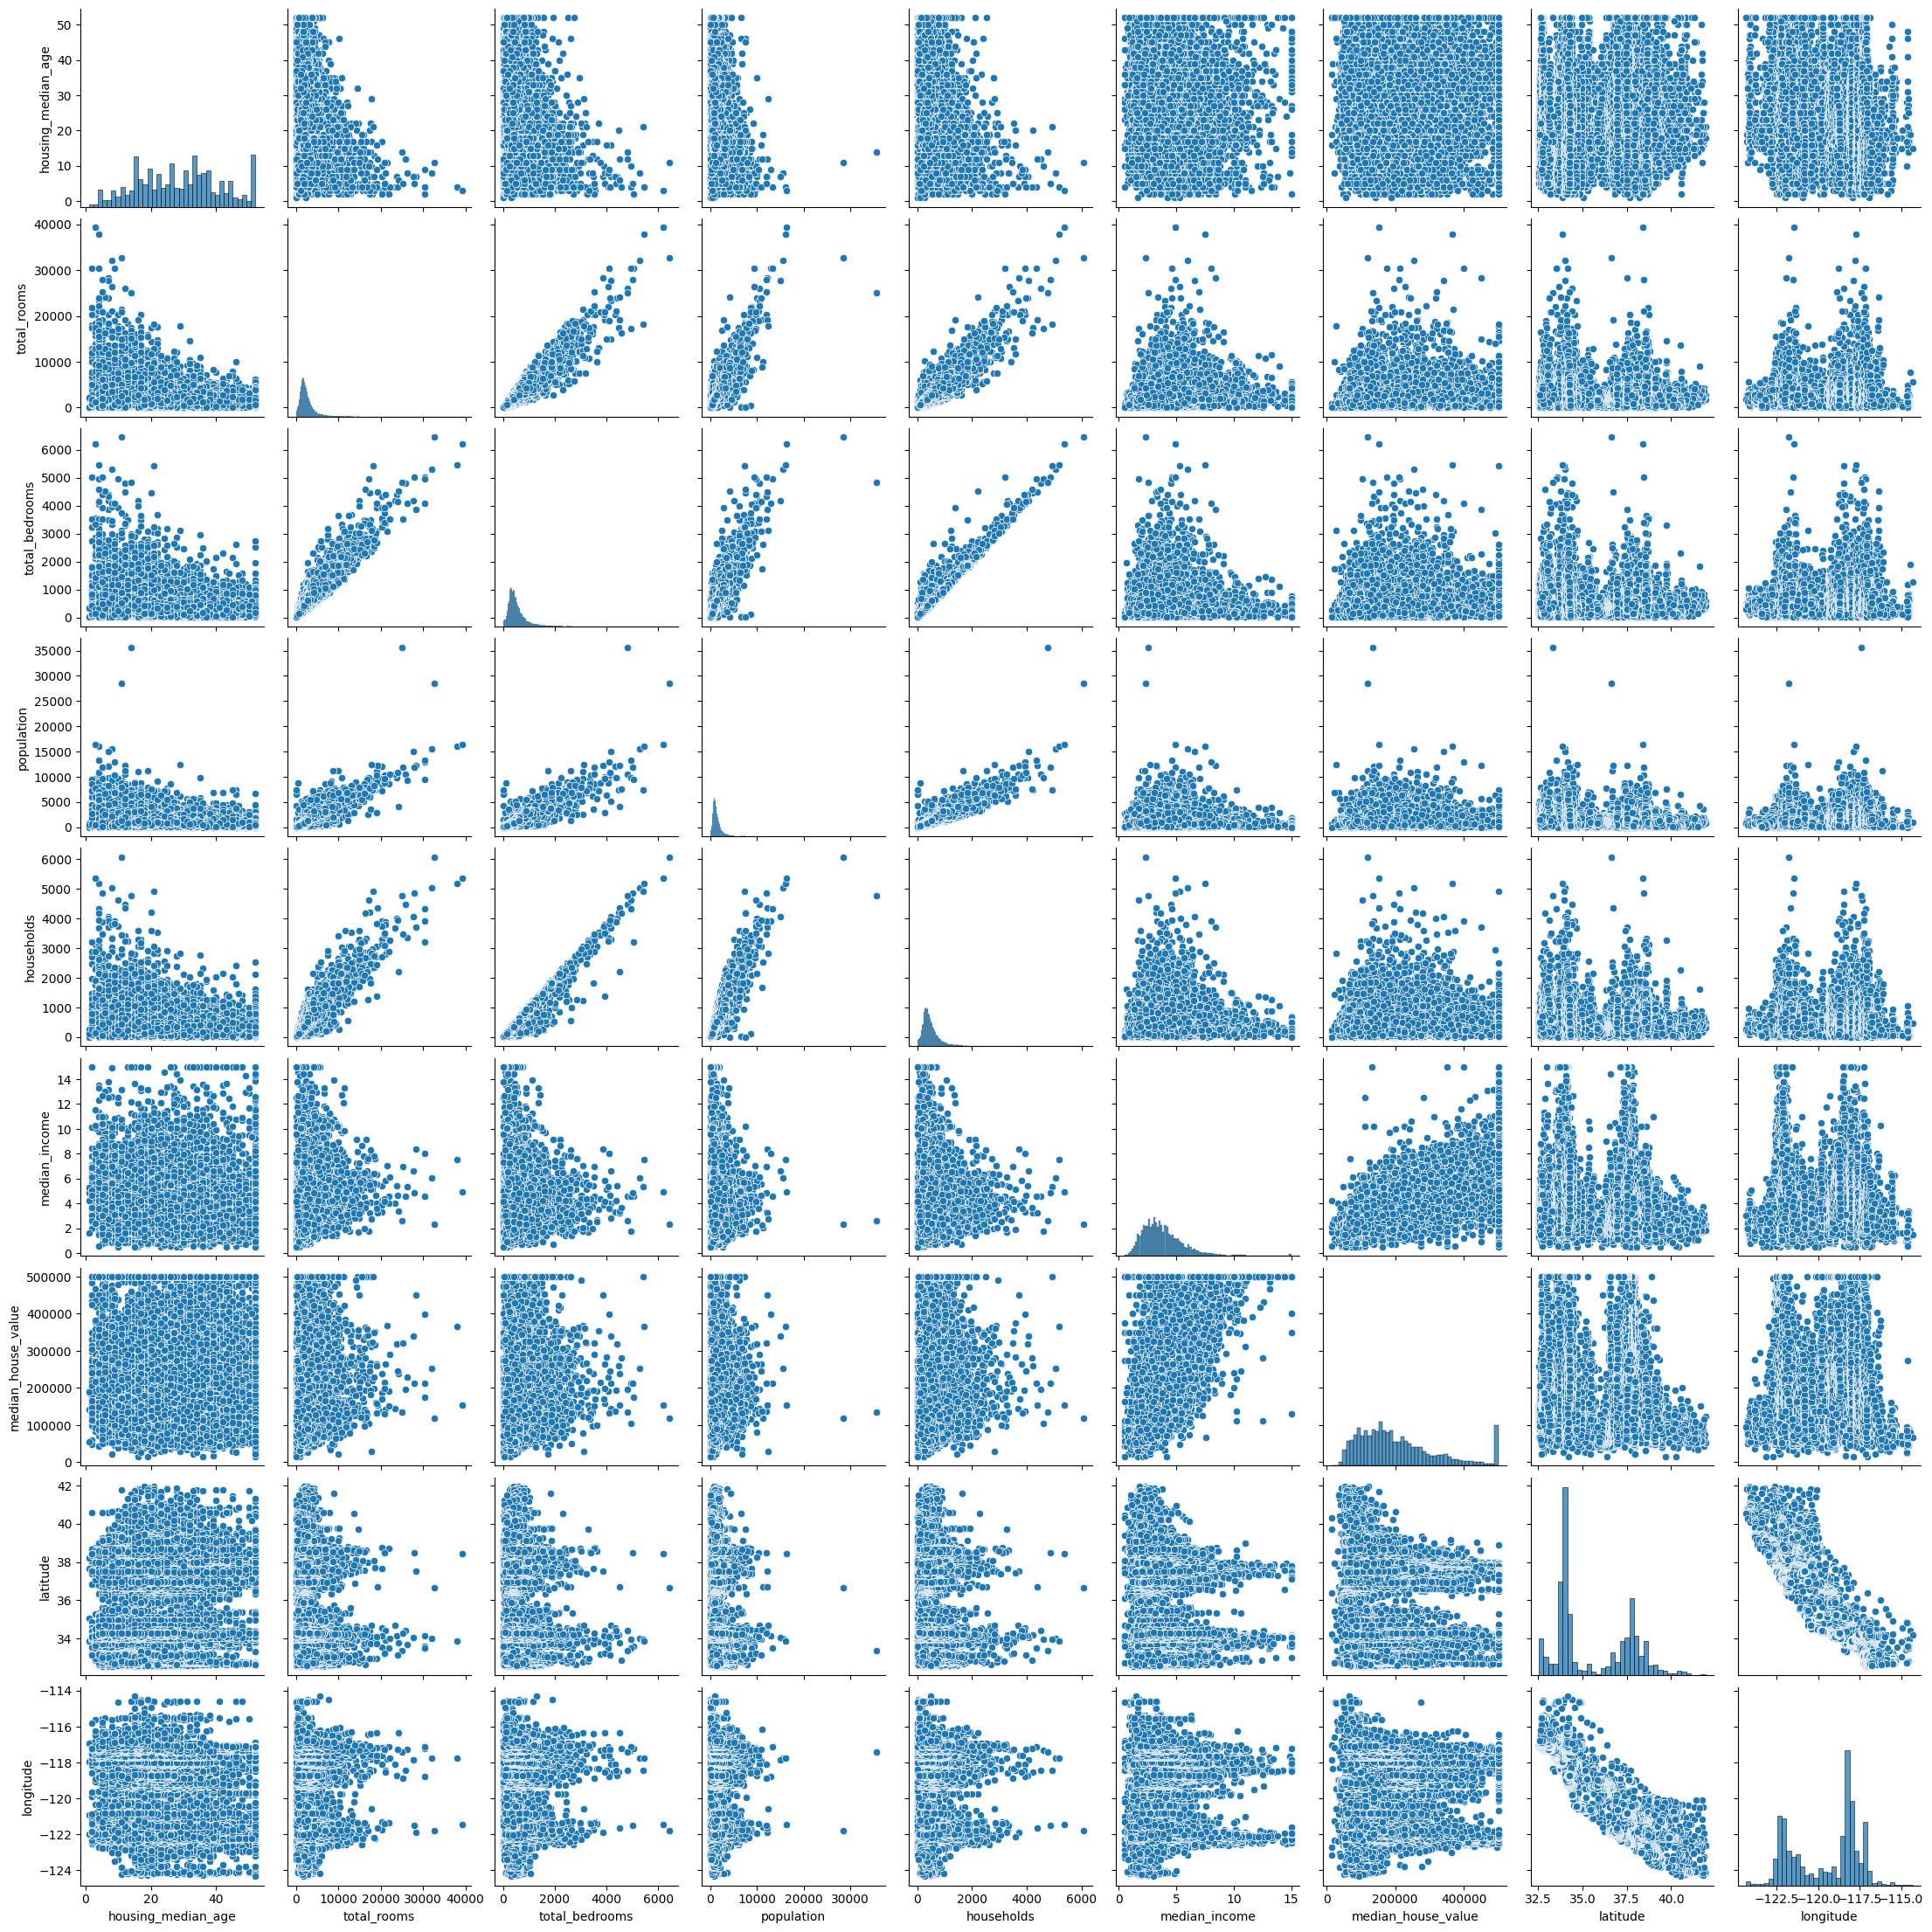

In [9]:
df2=df[['housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'latitude', 'longitude']]
sns.pairplot(data=df2)

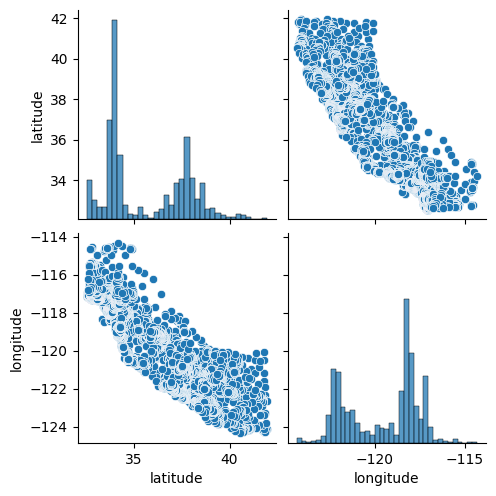

In [10]:
df2=df[['latitude', 'longitude']]
sns.pairplot(data=df2)

### Datos faltantes

In [11]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [12]:
(round(df.isna().sum() * 100 / df.shape[0], 2)).astype(str) + "%"

,0
longitude,0.0%
latitude,0.0%
housing_median_age,0.0%
total_rooms,0.0%
total_bedrooms,1.0%
population,0.0%
households,0.0%
median_income,0.0%
median_house_value,0.0%
ocean_proximity,0.0%


In [13]:
df_missing = df.isna().melt(value_name="missing")

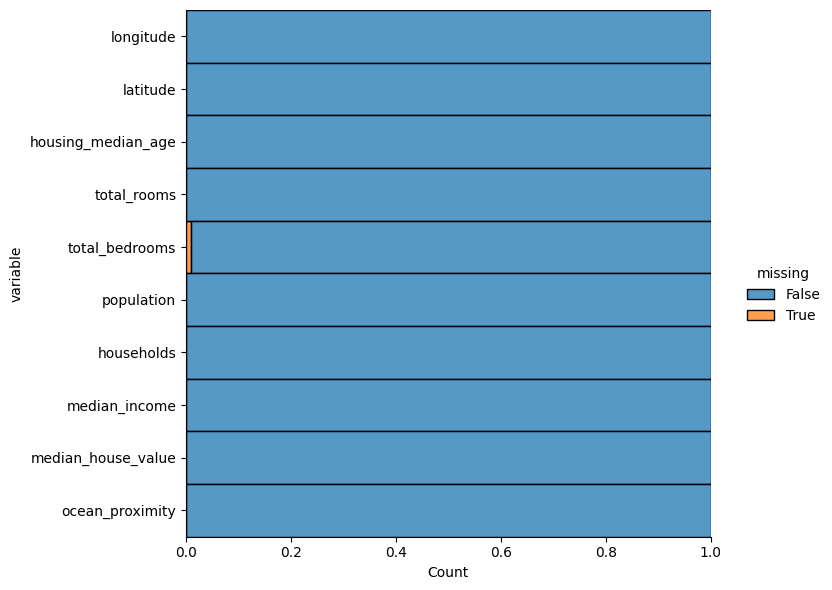

In [14]:
sns.displot(
    data=df_missing,
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.25,
    height=6
)

### Rellenamos los datos faltantes

Al ser tan bajo el número de datos faltantes rellenamos con alguna técnica para poder continuar con el objetivo del notebook, la regresión.

In [15]:
df['total_bedrooms'].fillna(int(df['total_bedrooms'].mean()), inplace=True)

/tmp/ipython-input-15-818059936.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(int(df['total_bedrooms'].mean()), inplace=True)


In [16]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


### Datos duplicados

In [17]:
df.duplicated().sum()

np.int64(0)

### Comprobación de valores atípicos y gestión de los mismos

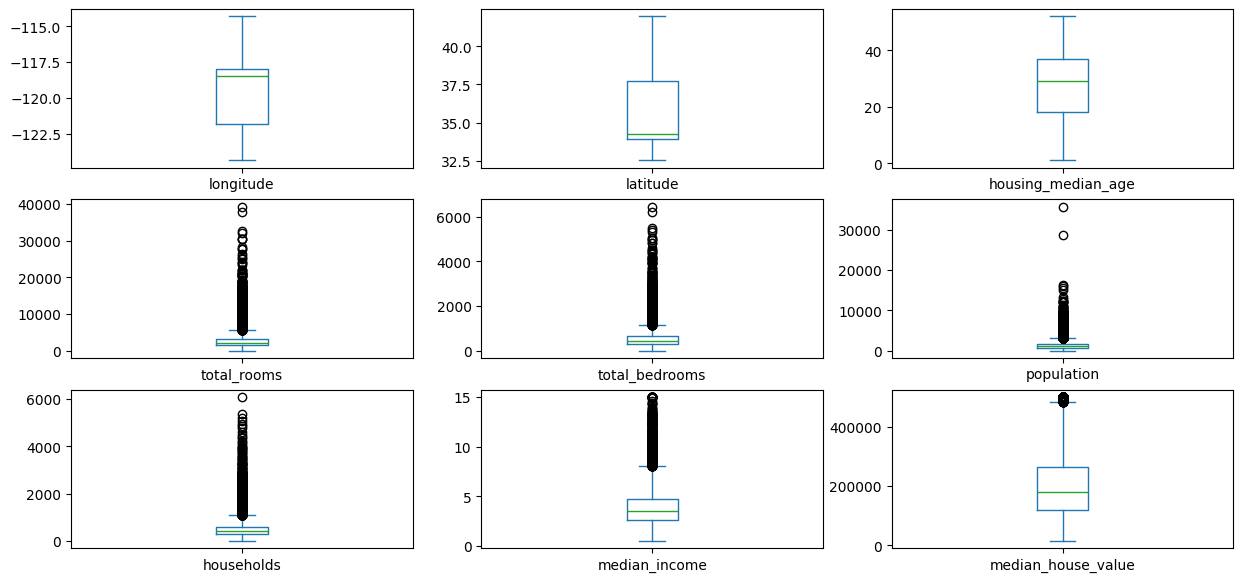

In [18]:
df.plot(kind='box', subplots=True,  layout=(3,3), figsize=(15,7))
plt.show()

In [19]:
columns = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

for column in columns:
    df = df[df[column] < df[column].quantile(0.9)]


In [20]:
df.shape

(12166, 10)

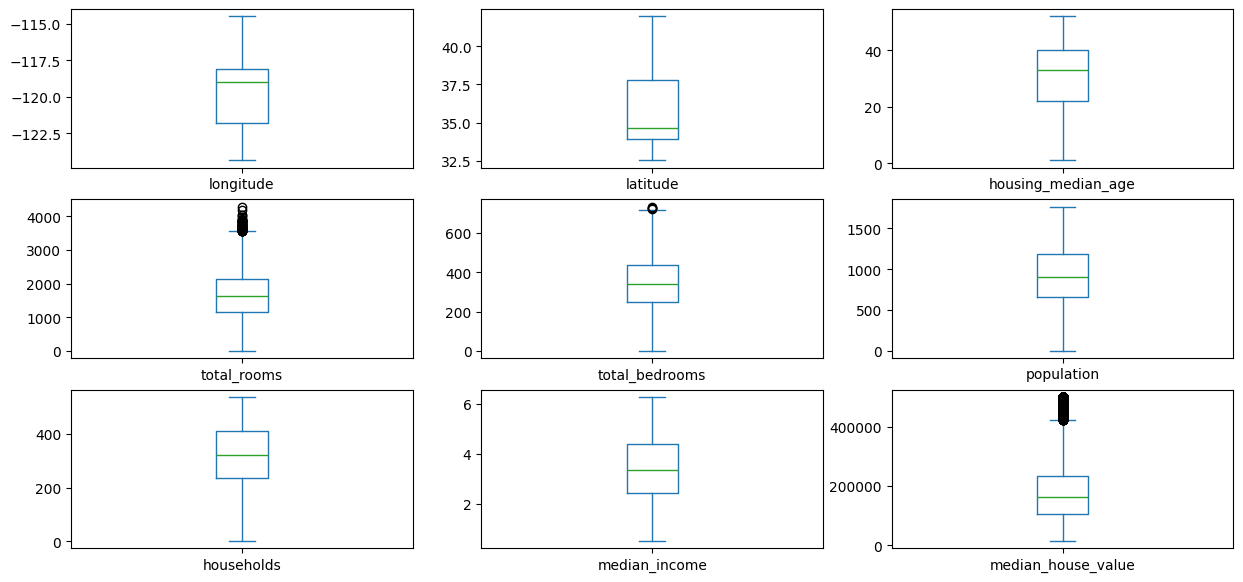

In [21]:
df.plot(kind='box', subplots=True, layout=(3,3), figsize=(15,7))
plt.show()

### EDA

In [22]:
ocean_values = df["ocean_proximity"].value_counts()
ocean_values

,count
ocean_proximity,
<1H OCEAN,4979
INLAND,4333
NEAR OCEAN,1492
NEAR BAY,1357
ISLAND,5


/tmp/ipython-input-23-3743470092.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = ocean_values[i]


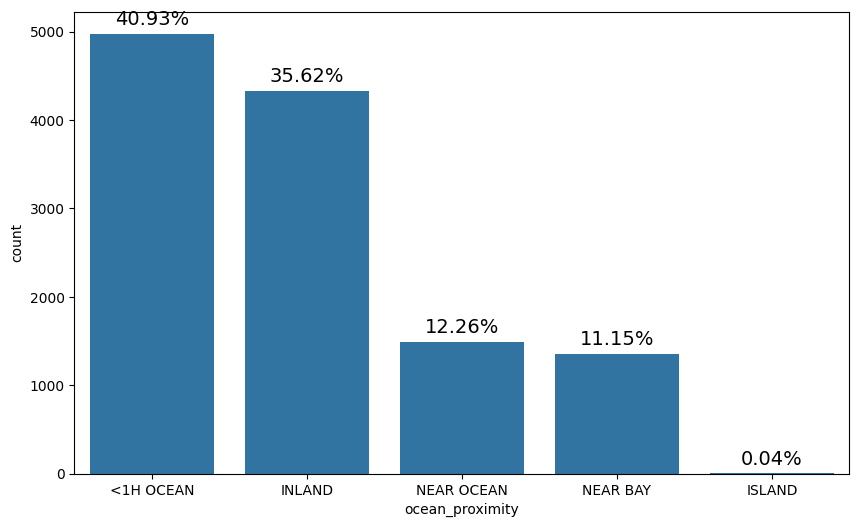

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(x = "ocean_proximity",data=df,order=ocean_values.index)

# porcentaje
for i in range(ocean_values.shape[0]):
    count = ocean_values[i]
    strt='{:0.2f}%'.format(100*count / df.shape[0])
    plt.text(i, count+100, strt, ha='center', color='black', fontsize=14)


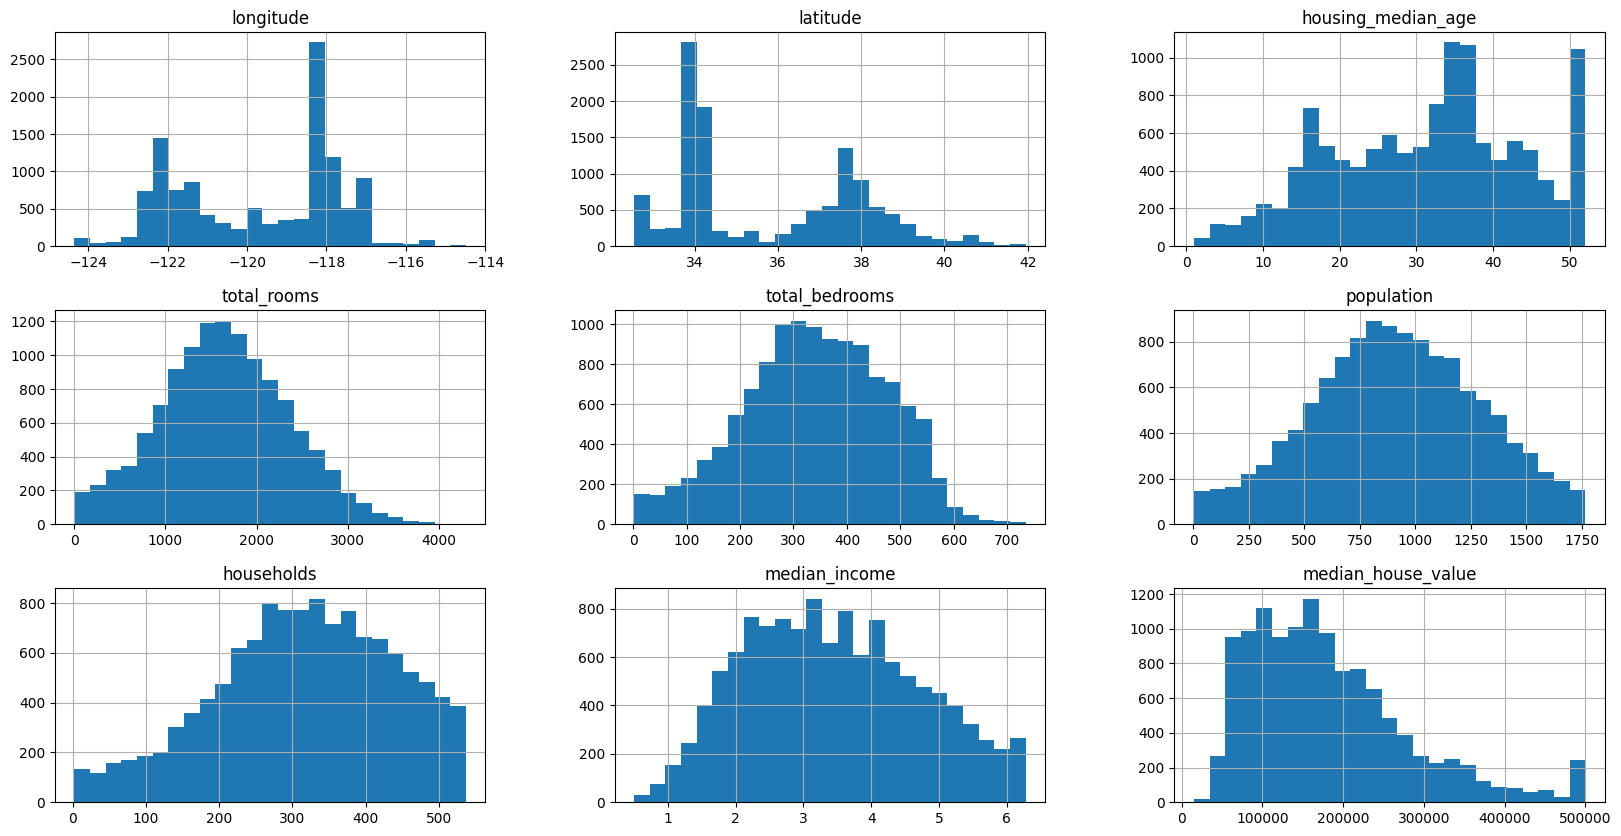

In [24]:
# Histograma
df.hist(bins=25,figsize=(20,10));

Text(0.5, 1.0, 'Linear correlation Median income/Median House value')

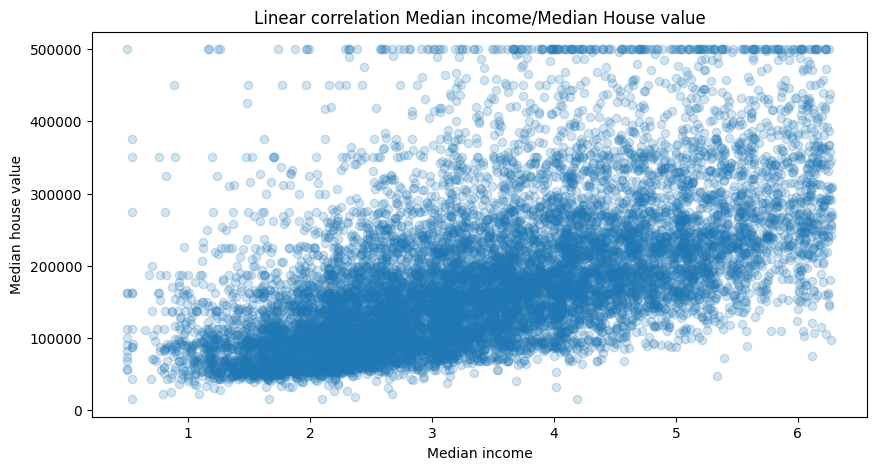

In [25]:
# Correlación entre el median_income y la median_house_value
plt.figure(figsize=(10,5))
plt.scatter(df["median_income"],df["median_house_value"], alpha=0.2)
plt.xlabel('Median income')
plt.ylabel('Median house value')
plt.title('Linear correlation Median income/Median House value')

Una última cosa que se puede hacer antes de preparar los datos para los algoritmos de aprendizaje automático es probar varias combinaciones de atributos. Por ejemplo, el número total de habitaciones de un distrito no es muy útil si no se sabe cuántos hogares hay en cada distrito. Lo que realmente se quiere es el número de habitaciones por hogar.

Text(0.5, 1.0, 'Distribución de Ingresos')

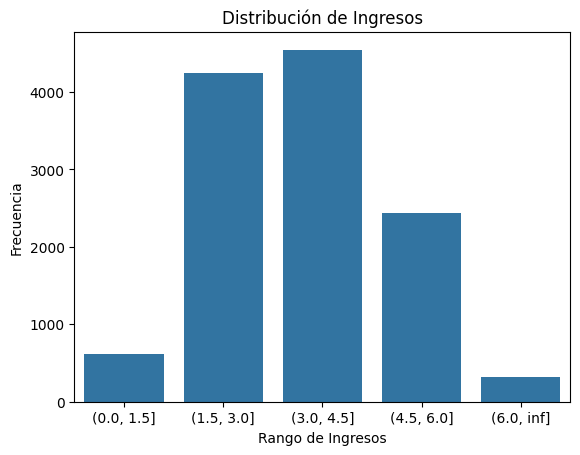

In [26]:
income_bins = pd.cut(df["median_income"], bins=[0,1.5,3,4.5,6,np.inf])
sns.countplot(x = income_bins)

plt.xlabel('Rango de Ingresos')
plt.ylabel('Frecuencia')
plt.title('Distribución de Ingresos')

Text(0.5, 1.0, 'Distribución de Ingresos')

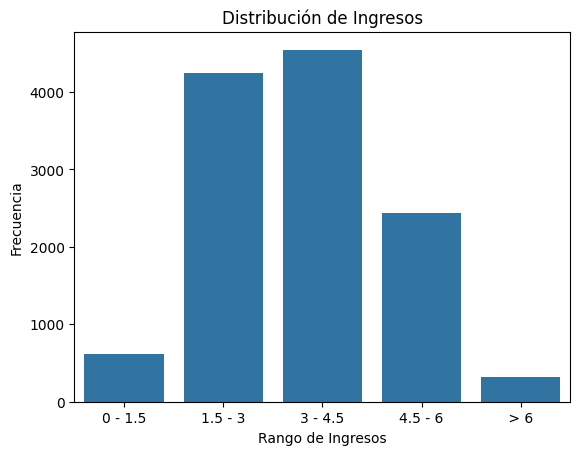

In [27]:
## Try to make median_income into bins
income_bins = pd.cut(df["median_income"],
                     bins=[0,1.5,3,4.5,6,np.inf], labels=["0 - 1.5","1.5 - 3","3 - 4.5","4.5 - 6"," > 6 "])
sns.countplot(x = income_bins)

plt.xlabel('Rango de Ingresos')
plt.ylabel('Frecuencia')
plt.title('Distribución de Ingresos')

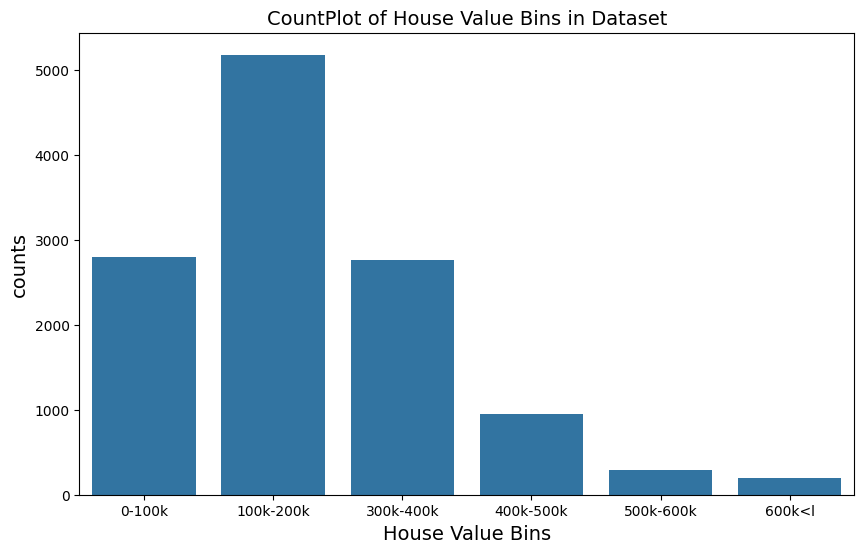

In [28]:
house_value_bins = pd.cut(x=df["median_house_value"],
                          bins=(-np.inf, 100000, 200000, 300000, 400000, 500000, np.inf),
                                labels=('0-100k', '100k-200k', '300k-400k', '400k-500k', '500k-600k', '600k<l') )
## countpLot for the above chunks
plt.figure(figsize=(10,6))
sns.countplot(x=house_value_bins)
plt.title('CountPlot of House Value Bins in Dataset', fontsize=14, c='k')
plt.xlabel('House Value Bins', fontsize=14, c='k')
plt.ylabel('counts', fontsize=14,c='k')
plt.show()

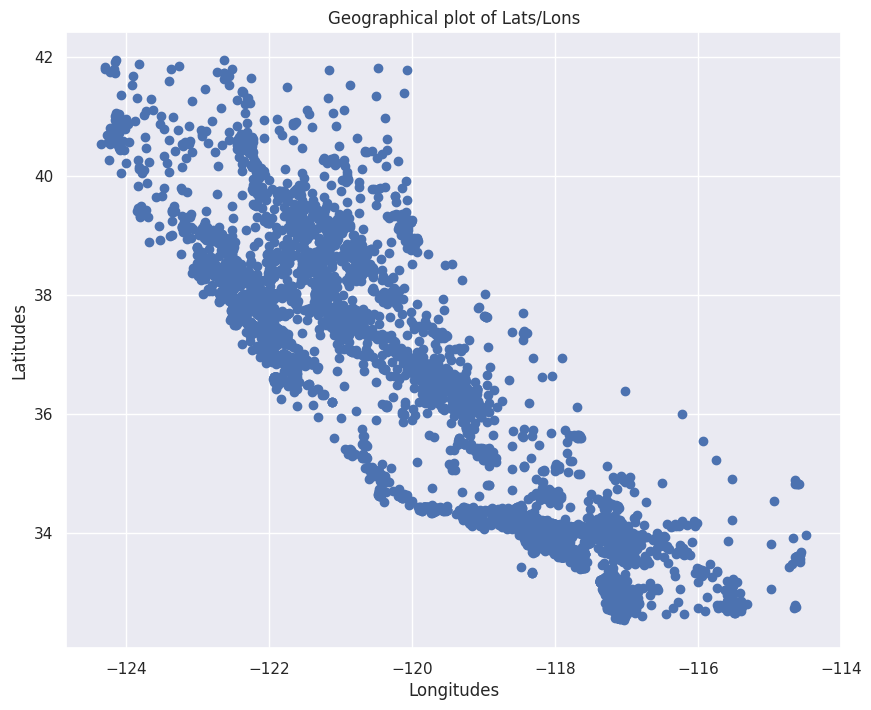

In [29]:
sns.set()
plt.figure(figsize=(10,8))#Figure size
plt.scatter('longitude','latitude',data=df)
plt.ylabel('Latitudes')
plt.xlabel('Longitudes')
plt.title('Geographical plot of Lats/Lons')
plt.show()


Ahora es mucho mejor, y si estamos familiarizados con el mapa de California podemos ver claramente que las zonas de alta densidad, la zona de la bahía y todos los alrededores de Los Ángeles y San Diego.

<Figure size 1000x700 with 0 Axes>

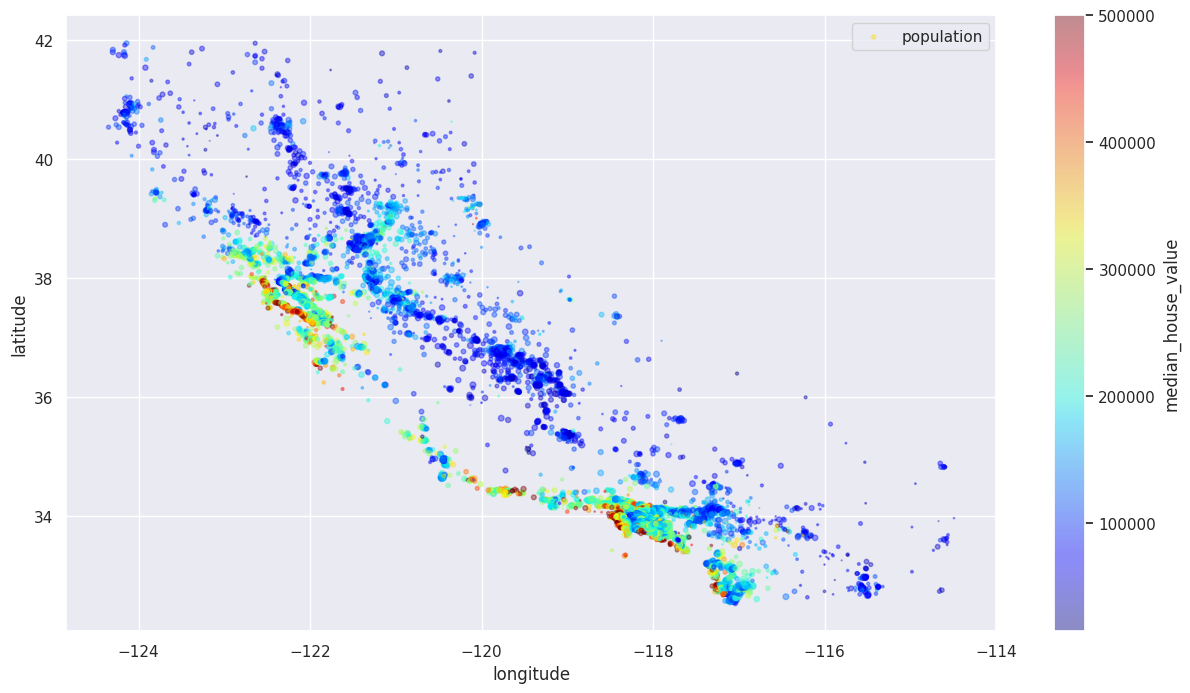

In [30]:
plt.figure(figsize=(10,7));
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
        s=df["population"]/100, label="population", figsize=(15,8),
        c="median_house_value", cmap=plt.get_cmap("jet"),colorbar=True,
    );
plt.legend();

Ahora podemos decir que el precio de la vivienda está un poco relacionado con la ubicación (por ejemplo, cerca del océano) y con la densidad de población.

In [31]:
pip install folium --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: folium
    Found existing installation: folium 0.19.7
    Uninstalling folium-0.19.7:
      Successfully uninstalled folium-0.19.7


In [32]:
import patsy
import folium
from folium import plugins
from folium.plugins import HeatMap
california_map = folium.Map(location=[36.7783,-119.4179], zoom_start = 6, min_zoom=5)

df_map = df[['latitude', 'longitude']]
data = [[row['latitude'],row['longitude']] for index, row in df_map.iterrows()]
_ = HeatMap(data, radius=10).add_to(california_map)

california_map

### Division de datos Train-Test Split (datos de entrenamiento y testeo)

La división entrenamiento-testeo es una técnica para evaluar el rendimiento de un algoritmo de aprendizaje automático.

Puede utilizarse para problemas de clasificación o regresión y para cualquier algoritmo de aprendizaje supervisado.

El procedimiento consiste en tomar un conjunto de datos y dividirlo en dos subconjuntos. El primer subconjunto se utiliza para ajustar el modelo y se denomina conjunto de datos de **entrenamiento**. El segundo subconjunto no se utiliza para entrenar el modelo; en su lugar, se proporciona al modelo el elemento de entrada del conjunto de datos y, a continuación, se realizan predicciones y se comparan con los valores esperados. Este segundo conjunto de datos se denomina conjunto de datos de **testeo**.

**Conjunto de datos de entrenamiento:** Se utiliza para ajustar el modelo de aprendizaje automático.

**Conjunto de datos de prueba:** Se utiliza para evaluar el modelo de aprendizaje automático ajustado.

El objetivo es estimar el rendimiento del modelo de aprendizaje automático con datos nuevos: datos no utilizados para entrenar el modelo, datos que no conoce.

Así es como esperamos utilizar el modelo en la práctica. Es decir, ajustarlo a los datos disponibles con entradas y salidas conocidas y, a continuación, realizar predicciones sobre nuevos ejemplos en el futuro en los que no dispongamos de los valores de salida u objetivo esperados.

#### Cómo configurar la división entrenamiento-testeo

El procedimiento tiene un parámetro de configuración principal, que es el tamaño de los conjuntos de entrenamiento y prueba. Normalmente se expresa como un porcentaje entre 0 y 1 para los conjuntos de datos de entrenamiento o de prueba.

Por ejemplo, un conjunto de entrenamiento con un tamaño de 0,67 (67 por ciento) significa que el porcentaje restante 0,33 (33 por ciento) se asigna al conjunto de prueba.

No existe un porcentaje de división óptimo.

Debe elegir un porcentaje de división que cumpla los objetivos de su proyecto teniendo en cuenta, entre otras cosas

* Coste computacional del entrenamiento del modelo.
* Coste computacional de la evaluación del modelo.
* Representatividad del conjunto de entrenamiento.
* Representatividad del conjunto de pruebas.

No obstante, los porcentajes de división más habituales son:

* Entrenamiento: 80%, Prueba: 20%.
* Entrenamiento: 70%, Prueba: 30%
* Entrenamiento: 67%, Prueba: 33%
* Entrenamiento: 50%, Prueba: 50%.

Ahora que estamos familiarizados con el procedimiento de evaluación de modelos divididos entrenamiento-testeo, veamos cómo podemos utilizar este procedimiento en Python.

In [33]:
target = 'median_house_value'

In [34]:
# Seleccionamos las variables de interes y dividimos en features y respuesta.

df=df[['housing_median_age',
       'total_rooms', 'total_bedrooms', 'population', 'households',
       'median_income','median_house_value']]

x = df[['housing_median_age',
       'total_rooms', 'total_bedrooms', 'population', 'households',
       'median_income']]

y= df[target ]

#### Procedimiento de división entenamiento-prueba en Scikit-Learn

La biblioteca de aprendizaje automático scikit-learn Python proporciona una implementación del procedimiento de evaluación de la división tren-prueba a través de la función [train_test_split()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

La función toma un conjunto de datos cargado como entrada y devuelve el conjunto de datos dividido en dos subconjuntos.

In [35]:
# Importamos la biblioteca

from sklearn.model_selection import train_test_split

In [36]:
x_train , x_test , y_train , y_test = train_test_split(x,y , test_size= 0.3 , random_state=42)

In [37]:
?train_test_split

In [38]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(8516, 6) (3650, 6) (8516,) (3650,)


In [39]:
x_train.describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,8516.000000,8516.000000,8516.000000,8516.000000,8516.00000,8516.000000
mean,31.491310,1644.846407,339.128934,908.318342,314.21853,3.439528
std,12.175659,710.640830,133.360206,380.258879,122.77461,1.291813
min,1.000000,2.000000,2.000000,3.000000,2.00000,0.499900
25%,22.000000,1165.000000,251.000000,648.000000,233.75000,2.412950
50%,33.000000,1621.000000,341.500000,906.500000,320.00000,3.348000
75%,40.000000,2121.000000,438.000000,1178.000000,408.00000,4.389700
max,52.000000,4293.000000,734.000000,1766.000000,537.00000,6.277800


[Material complementario division de datos](https://machinelearningmastery.com/train-test-split-for-evaluating-machine-learning-algorithms/)

#### sklearn.preprocessing.RobustScaler

Es recomendable el escalado de datos en el aprendizaje automático porque puede mejorar la precisión y el rendimiento de los modelos.

[sklearn.preprocessing.RobustScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)

Este Escalador elimina la mediana y escala los datos según el rango cuantílico (por defecto IQR: Interquartile Range). El IQR es el rango entre el 1er cuartil (cuantil 25) y el 3er cuartil (cuantil 75).

El centrado y el escalado se realizan de forma independiente en cada característica calculando los estadísticos relevantes en las muestras del conjunto de entrenamiento. A continuación, la mediana y el rango intercuartílico se almacenan para utilizarlos en datos posteriores mediante el método de transformación.

La normalización de un conjunto de datos es un requisito común para muchos estimadores de aprendizaje automático. Normalmente, esto se hace eliminando la media y escalando a la varianza unitaria. Sin embargo, los valores atípicos pueden influir negativamente en la media/varianza de la muestra. En estos casos, la mediana y el rango intercuartílico suelen dar mejores resultados.

Se puede utilizar otros normalizadores.
* **MinMaxScaler**: La normalización ajusta los valores de las características en un rango específico, generalmente entre 0 y 1.  
* **StandardScaler**: La estandarización transforma los valores de las características para tener una media de 0 y una desviación estándar de 1.

Elección Apropiada

- Distribuciones normales y sensibilidad a outliers: *StandardScaler*.
- Rango fijo necesario y menos preocupación por outliers: *MinMaxScaler*.
- Presencia de outliers y distribuciones desconocidas o no normales: *RobustScaler*.

In [40]:
from sklearn.preprocessing import RobustScaler
ro_scaler=RobustScaler()
x_train=ro_scaler.fit_transform(x_train)
x_test=ro_scaler.transform(x_test)

In [41]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(8516, 6) (3650, 6) (8516,) (3650,)


# Regresión Lineal

El objetivo de un modelo de regresión es tratar de explicar la relación que existe entre una variable dependiente (variable respuesta) $Y$, y un conjunto de variables independientes (variables explicativas) $X_1,..., X_n$.

En un modelo de regresión lineal simple tratamos de explicar la relación que existe entre la
variable respuesta $Y$ y una única variable explicativa $X$, por medio de una relación lineal.

#### Simple



$y = \beta_0 + \beta_1 x_1$

En donde $\beta_0$ es la ordenada en el origen (el valor que toma $Y$ cuando $X$ vale 0) y $\beta_1$  es la pendiente
de la recta (e indica cómo cambia $Y$ al incrementar $X$ en una unidad).

#### Múltiple



$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$

### Solución por Mínimos Cuadrados Ordinarios (MCO) (OLS)


Mínimos Cuadrados Ordinarios es un método común para estimar los coeficientes de las ecuaciones de regresión lineal que describen la relación entre una (o varias) variables independientes y la variable dependiente.

El método OLS tiene el objetivo de minimizar la suma de diferencias cuadradas entre los valores observadas y predichas.

## Ejemplo aplicación: ajustando una recta a un conjunto de datos



Tenemos un grupo de datos que relaciona dos variables, por ejemplo $(x_1, y_1), \dots ,(x_n, y_n)$ y queremos encontrar una función $f(x)$ que se ajuste a ese grupo de datos para así poder extrapolar los mismos valores no determinados experimentalmente o en el campo. Esa función puede ser una recta, una función exponencial, un polinomio, entre otras, y su elección en muchos casos dependerá del conocimiento que uno tenga del problema en cuestión.

Supongamos que a partir de un conjunto de datos ($y_n$, $x_n$) queremos ajustar una recta que tiene por ecuación $y=a_0+a_1x$. En esta ecuación $a_0$ representa la *ordenada al origen* y $a_1$ representa la *pendiente* de esa recta. Si bien existen diferentes formas de ajustar los datos, la forma más utilizada es la de mínimos cuadrados ordinarios (MCO) dado por la siguiente ecuación general:

$$E=\sum_{i=1}^{n} [y_n-(a_{1}x_n+a_{0})]^2$$

Esta ecuación expresa que el error de ajuste ($E$) es la suma de los cuadrados de las diferencias entre los valores de $y$ provistos por la recta de ajuste (dados por $ax_n+b$)  y los valores de $y$ medidos (dados por $y_n$). Como los valores de $y_n$ y $x_n$ son conocidos (pues son nuestros datos) todo se reduce a encontrar los valores de $a_{0}$ y $a_{1}$ que reducen el error al mínimo. Para lograr esto tomamos la derivada parcial de la ecuación anterior en función de las dos variables $a_{0}$ y $a_{1}$ y obtenemos el siguiente sistema de ecuaciones:

$$\dfrac{\partial E}{\partial a_{0}} = -2 \sum_{i=1}^{n} (y_n-a_{1}x_n-a_{0})$$
$$\dfrac{\partial E}{\partial a_{1}} = -2 \sum_{i=1}^{n} (y_n-a_{1}x_n-a_{0})x_n$$


Luego dividimos ambas ecuaciones por $-2$ e igualamos a cero (la razón por la que igualamos a cero es porque es cuando se minimiza el error, pues cuando la derivada de una función es igual a cero tenemos un mínimo). O sea $\dfrac{\partial E}{\partial a_{0}}=0$ y $\dfrac{\partial E}{\partial a_{1}}=0$) obteniendo lo que en mínimos cuadrados se conocen como las **ecuaciones normales**:


$$\sum_{i=1}^{n} (y_n-a_{1}x_n-a_{0})x_n =0 $$
$$\sum_{i=1}^{n} (y_n-a_{1}x_n-a_{0}) =0$$


Esto puede reescribirse de la siguiente manera:


$$\left(\sum_{i=1}^{n} x_n \right) a_{0} - \left(\sum_{i=1}^{n} x_n^{2}\right) a_{1}  = -\left(\sum_{i=1}^{n} y_n x_n\right)$$

$$\left(\sum_{i=1}^{n} 1\right) a_{0} - \left(\sum_{i=1}^{n} x_n\right) a_{1}   = -\left(\sum_{i=1}^{n} y_n\right)$$

Luego de algunas manipulaciones algebraicas podemos obtener la solución para $a_{0}$ y $a_{1}$ del sistema de ecuaciones que se detalla a continuación (ver más detalles de una derivación similar en *Numerical Analysis* de Burden y Faires, pag. 518 y en *Linear Algebra* de Gilbert Strang, pag. 197):

 $$a_{0} = \dfrac{\sum\limits_{i=1}^{n} x_n^{2} \sum\limits_{i=1}^{n} y_n - \sum\limits_{i=1}^{n} x_n y_n \sum\limits_{i=1}^{n} x_n}{n\left(\sum\limits_{i=1}^{n} x_n^{2}\right) - \left(\sum\limits_{i=1}^{n} x_n\right)^{2}}$$

$$ a_{1} = \dfrac{\sum\limits_{i=1}^{n} x_n y_n - \sum\limits_{i=1}^{n} x_n  \sum\limits_{i=1}^{n} y_n}{n\left(\sum\limits_{i=1}^{n} x_n^{2}\right) - \left(\sum\limits_{i=1}^{n} x_n\right)^{2}} $$

Veamos esto mediante un ejemplo. Supongamos que tenemos un conjunto de datos ($x_n$ e $y_n$) de isótopos de carbono y oxígeno en carbonatos sedimentarios y que están expresados de la siguiente forma:

|$x_n$     | $\delta^{13}C$ |$y_n$       |$\delta^{18}O$ |
|----------|----------------|------------|---------------|
|$x_1$     | 8.87           | $y_1$      | 0.31          |
|$x_2$     | 8.29           | $y_2$      | -0.13         |
|$x_3$     | 8.49           | $y_3$      | -0.06         |
|$x_4$     | 8.75           | $y_4$      | -0.31         |
|$x_5$     | 8.86           | $y_5$      | 0.35          |
|$x_6$     | 9.23           | $y_6$      | 0.20          |
|$x_7$     | 10.75          | $y_7$      | 1.80          |
|$x_8$     | 10.00          | $y_8$      | 0.57          |
|$x_9$     | 10.15          | $y_9$      | 1.11          |
|$x_{10}$  | 10.01          | $y_{10}$   | 1.61          |


Para aplicar las ecuaciones para determinar $a_0$ y $a_1$  al ejemplo de la tabla de valores de $\delta^{13}C$ y $\delta^{18}O$ obtenemos primero las siguientes sumatorias:

|$\sum\limits_{i=1}^{n} x_n$ | $\sum\limits_{i=1}^{n} x_{n}^{2}$ |  $\sum\limits_{i=1}^{n} x_n y_n$    | $\sum\limits_{i=1}^{n} y_n$ |
|------------------------------|----------|---------------|-------------|
|93.400                        | 878.521  | 55.829        |     5.450   |

Luego reemplazamos en las ecuaciones para calcular $a_0$ y $a_1$:

 $$a_{0} = \dfrac{\sum\limits_{i=1}^{n} x_n^{2} \sum\limits_{i=1}^{n} y_n - \sum\limits_{i=1}^{n} x_n y_n \sum\limits_{i=1}^{n} x_n}{n\left(\sum\limits_{i=1}^{n} x_n^{2}\right) - \left(\sum\limits_{i=1}^{n} x_n\right)^{2}} = \dfrac{878.521 \cdot 5.450 -55.829 \cdot 93.400}{10 \cdot 878.521 - 8723.560} = -6.919$$

 $$a_{1} = \dfrac{n\sum\limits_{i=1}^{n} x_n y_n - \sum\limits_{i=1}^{n} x_n  \sum\limits_{i=1}^{n} y_n}{n\left(\sum\limits_{i=1}^{n} x_n^{2}\right) - \left(\sum\limits_{i=1}^{n} x_n\right)^{2}} = \dfrac{10 \cdot 55.829 - 93.400 \cdot 5.450}{10 \cdot 878.521 - 8723.56} = 0.799$$


In [42]:
#creo dos arrays con los valores de x e y--------------------------
#Los datos son de Gomez et al., 2014.
xn=np.array([8.87, 8.29, 8.49, 8.75, 8.86, 9.23, 10.75, 10.00, 10.15, 10.01])

yn=np.array([0.31, -0.13, -0.06, -0.31, 0.35, 0.20, 1.80, 0.57, 1.11, 1.61])

#obtengo el valor de n (numero de datos)
n=len(xn)

#Hago las sumatorias y demas operaciones-----------------------------
Sum_x=sum(xn)
Sum_y=sum(yn)
Sum_xx=sum(xn**2)
Sum_xy=sum(xn*yn)

#imprimo los valores para verlos-------------------------------------
print(Sum_x, Sum_y, Sum_xx, Sum_xy)

93.4 5.45 878.5212 55.8297


-6.918728346201453 0.7991143839616138


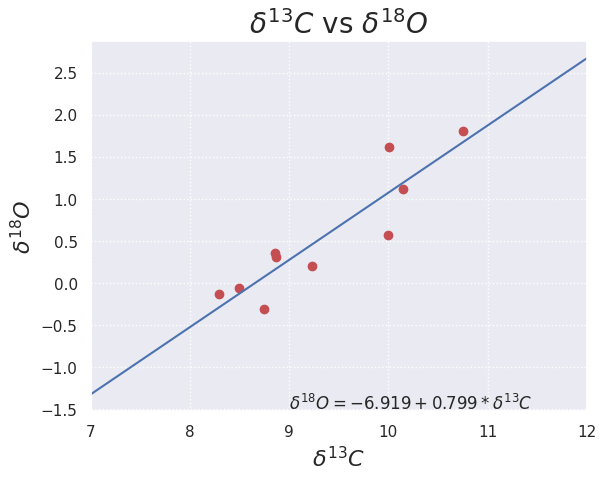

In [43]:
#ahora reemplazo en a_0 y a_1 y los imprimo  para visualizarlos------
a_0=(Sum_xx*Sum_y-Sum_xy*Sum_x)/(n*Sum_xx-Sum_x**2)
a_1=(n*Sum_xy-Sum_x*Sum_y)/(n*Sum_xx-Sum_x**2)
print(a_0, a_1)

#Genero valores para plotear la recta segun a_0 y a_1----------------
xj=np.linspace(7, 12, 2)
yj=a_0+a_1*xj

#Gráfico de los puntos y la recta de ajuste--------------------------
plt.figure(1)
plt.scatter(xn, yn, color='r')
plt.grid(linestyle='dotted')
plt.plot(xj, yj, color='b')
plt.title(r'$\delta ^{13}C$ vs $\delta ^{18}O$', fontsize=20)
plt.xlabel(r'$\delta ^{13}C$', fontsize=16)
plt.ylabel(r'$\delta ^{18}O$', fontsize=16)
plt.xlim(7, 12)
plt.text(9, -1.5, r'$\delta ^{18}O=-6.919+0.799*\delta ^{13}C$',
    fontsize=12)

plt.show()
#--------------------------------------------------------------------

### Métricas de evaluación de modelos


Es importante destacar que muchas veces tenemos que elegir cuál es el mejor modelo que ajusta a nuestros datos. Para ello debemos compararlos. Esto se realiza a partir de métricas.

Existen muchas métricas para determinar el rendimiento de los modelos de aprendizaje automático. Es beneficioso saber qué métrica de evaluación medirá adecuadamente el rendimiento. Algunas métricas miden el rendimiento del modelo mejor que otras, dependiendo de cada caso de uso. Repasaremos algunas de las métricas de evaluación más comunes para los problemas de regresión.

### MAE (Mean Absolute Error)

El error absoluto medio calcula la diferencia absoluta entre los valores observados y los valores predichos del modelo. El MAE es una buena referencia, ya que analiza el error absoluto. El problema de utilizar MAE es que la métrica es relativa a los valores y residuos. Por ejemplo, ¿qué se considera un MAE bueno o malo? Obviamente nos gustaría tener MAE cerca de 0, pero cuando los errores son valores grandes se hace más difícil evaluar el modelo usando MAE.


Fórmula para calcular MAE:

$$MAE = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$

In [44]:
import numpy as np

# Valores reales
y_true = np.array([1.2, 2.5, 3.8, 4.1, 5.2])

# Valores predichos
y_pred = np.array([1.5, 2.8, 3.4, 3.9, 4.7])

# Calcular el MAE
mae = np.mean(np.abs(y_true - y_pred))

# Imprimir el MAE
print("MAE:", mae)


MAE: 0.3399999999999999


In [45]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_true, y_pred)

# Imprimir el MAE
print("MAE:", mae)

MAE: 0.3399999999999999


### MSE (Mean Squared Error)

El error cuadrático medio calcula el error y luego eleva la diferencia al cuadrado, antes de calcular la media o promedio. MSE es otra buena métrica para utilizar como referencia, ya que es una métrica de evaluación fundamental como MAE. Sin embargo, el MSE infla los errores, ya que cada valor se eleva al cuadrado. De nuevo, esto dificulta la evaluación del modelo.

Fórmula para calcular el MSE:

$$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

In [46]:
mse = np.mean((y_true - y_pred) ** 2)

# Imprimir el MSE
print("MSE:", mse)

MSE: 0.12599999999999995


In [47]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_true, y_pred)

# Imprimir el MSE
print("MSE:", mse)

MSE: 0.12599999999999995


### RMSE (Root Mean Squared Error)

La raíz del error cuadrático medio es igual que el error cuadrático medio, pero tomando la raíz cuadrada del resultado. El RMSE es otra métrica de evaluación fundamental basada en el cuadrado de los residuos, pero penaliza más los errores más grandes.

Fórmula para calcular el RMSE:

$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$

In [48]:
# Calcular el MSE
mse = np.mean((y_true - y_pred) ** 2)

# Calcular el RMSE
rmse = np.sqrt(mse)

# Imprimir el RMSE
print("RMSE:", rmse)

RMSE: 0.3549647869859769


In [49]:
from sklearn.metrics import mean_squared_error
# Calcular el MSE
mse = mean_squared_error(y_true, y_pred)

# Calcular el RMSE
rmse = np.sqrt(mse)

# Imprimir el RMSE
print("RMSE:", rmse)

RMSE: 0.3549647869859769


### MAPE (Mean Absolute Percentage Error)

El Error Medio Porcentual Absoluto intenta resolver el problema del MAE, en el que MAE se convierte en relativo basado en la escala de sus residuos. MAPE transformará los errores en porcentajes, donde se desea que el MAPE sea lo más cercano a 0 como sea posible. También existen otras métricas que utilizan valores absolutos y porcentajes. (por ejemplo, APE, MAPE ponderado, MAPE simétrico, etc.)

Fórmula para calcular el MAPE:

$$MAPE = \frac{1}{N} \sum_{i=1}^{N} {|\frac{y_i - \hat{y}_i}{y_i}|}$$

In [50]:
mape = np.mean(np.abs((y_true - y_pred) / y_true))

# Imprimir el MAPE
print("MAPE:", mape)

MAPE: 0.1240394983706922


### MASE (Mean Absolute Scaled Error)

El MASE es una métrica que permite comparar dos modelos. Utilizando el MAE de cada modelo, puede poner el MAE del nuevo modelo en el numerador y el MAE del modelo original en el denominador. Si el valor MASE es inferior a 1, el nuevo modelo funciona mejor. Si el valor MASE es igual a 1, los modelos tienen el mismo rendimiento. Si el valor de MASE es superior a 1, el modelo original funciona mejor que el nuevo.

Fórmula para calcular MASE:

$$MASE = \frac{MAE_i}{MAE_j}$$

### Coeficiente de determinación $R^2$

Otra métrica de evaluación de modelos predictivos es el coeficiente de determinación (*coefficient of determination ($R^2$)*). Calculada bajo las predicciones en la base de datos de entrenamiento estima la proporción de la varianza de la variable respuesta que puede ser explicada por el modelo, brindando una medida de bondad de ajuste del modelo. Por otra parte, bajo una base de datos de testeo representa la capacidad predictiva del modelo ajustado. El $R^2$ toma valores entre 0 y 1, donde 0 indica que el modelo no explica nada de la variabilidad de la variable respuesta (entrenamiento), o bien que la capacidad predictiva del modelo es deficiente (testeo), mientras que 1 indica que el modelo explica la totalidad de la variabilidad (entrenamiento), o bien que estamos frente a un modelo perfecto (testeo).

\begin{equation*}
R^2 = 1-\frac{SSE}{SST}
\end{equation*}
  
  Donde SSE  es la suma de cuadrados de las diferencias entre los valores observados y los predichos y SST es la variación total en los datos también conocida como suma total al cuadrado.

\begin{equation*}
SSE = \sum\nolimits_{i=1}^N(y_i - \hat{y_i})^2
\end{equation*}

\begin{equation*}
SST = \sum\nolimits_{i=1}^N(y_i-\overline{y})^2
\end{equation*}

  Donde $y_i$ es el valor y para la observación i, $\overline{y}$ es la media del valor y y $\hat{y_i}$ es el valor predicho de y para la observación i.



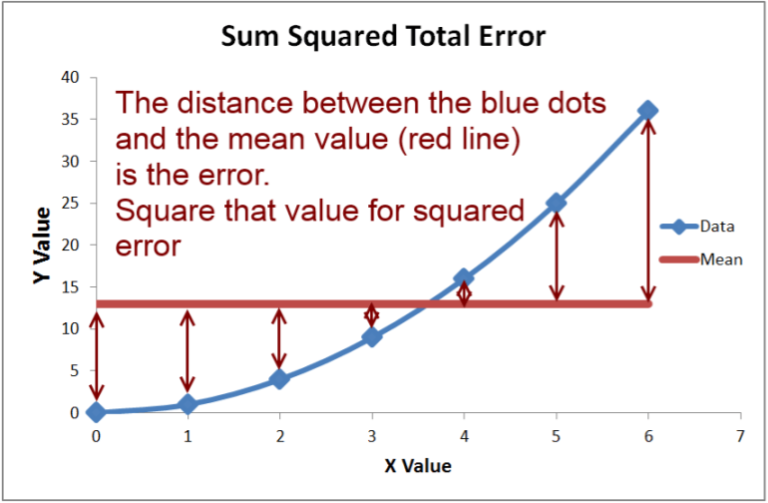

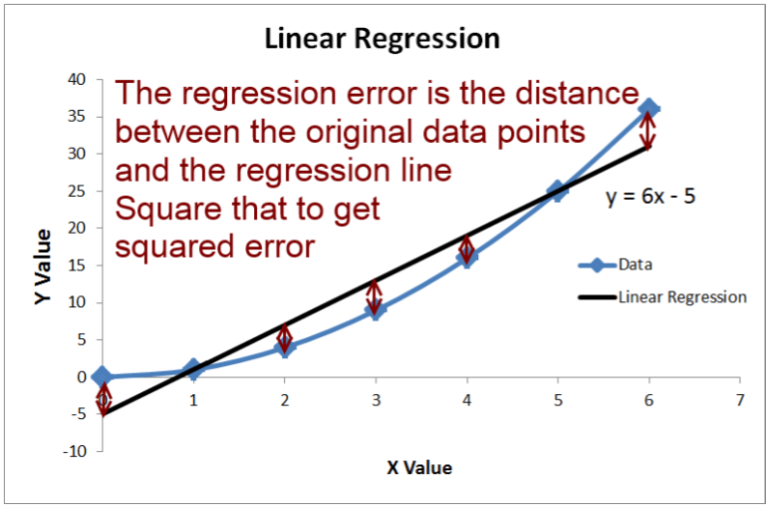

In [51]:
# Datos reales
y_true = np.array([3, 5, 7, 9, 11, 13])

# Datos predichos
y_pred = np.array([4, 6, 8, 10, 12, 14])

y_mean = np.mean(y_true)

# Suma de Cuadrados de los Errores
sse = np.sum((y_true - y_pred) ** 2)

# Suma Total de Cuadrados
sst = np.sum((y_true - y_mean) ** 2)

# Coeficiente de Determinación R^2
r2 = 1 - (sse / sst)

# Imprimir el valor de R^2
print("R^2:", r2)

R^2: 0.9142857142857143


In [52]:
from sklearn.metrics import r2_score

# Datos reales
y_true = np.array([3, 5, 7, 9, 11, 13])

# Datos predichos
y_pred = np.array([4, 6, 8, 10, 12, 14])

# Calcular el coeficiente de determinación R^2
r2 = r2_score(y_true, y_pred)

# Imprimir el valor de R^2
print("R^2:", r2)

R^2: 0.9142857142857143



#### $R²$ en resumen

---

* Un valor de $R^2$ de 1.0 es lo mejor que podemos conseguir. Indica que no hay ningún error en la regresión.

* Un valor de $R^2$ de 0 significa que la regresión no es mejor que tomar el valor medio, es decir no estamos usando ninguna información de otras variables.

* Un valor negativo de $R^2$, significa que estamos estimando peor que usando la media.  


Material complementario:

Scikit Learn tiene múltiples [funciones de métricas de evaluación](https://scikit-learn.org/stable/modules/model_evaluation.html).

## Ajuste de regresión lineal

Volvemos al problema del precio de las casas y realizamos el ajuste de la regresión lineal. Para ello implementaremos la biblioteca de `scikit-learn`.

[sklearn.linear_model.LinearRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [53]:
from sklearn import linear_model
model = linear_model.LinearRegression()

xn=np.array([8.87, 8.29, 8.49, 8.75, 8.86, 9.23, 10.75, 10.00, 10.15, 10.01])
yn=np.array([0.31, -0.13, -0.06, -0.31, 0.35, 0.20, 1.80, 0.57, 1.11, 1.61])

In [54]:
model.fit(xn.reshape(-1,1),yn)

LinearRegression()

In [55]:
xn

array([ 8.87,  8.29,  8.49,  8.75,  8.86,  9.23, 10.75, 10.  , 10.15,
       10.01])

In [56]:
xn.reshape(-1,1)

array([[ 8.87],
       [ 8.29],
       [ 8.49],
       [ 8.75],
       [ 8.86],
       [ 9.23],
       [10.75],
       [10.  ],
       [10.15],
       [10.01]])

In [57]:
model.score(xn.reshape(-1,1),yn)

0.8212256516856454

In [58]:
model.intercept_

np.float64(-6.918728346201257)

In [59]:
model.coef_

array([0.79911438])

$$
y_n=-6.918+0.799*x_n
$$

In [60]:
x_nuevos = np.array([1,2,3])
model.predict(x_nuevos.reshape(-1,1))

array([-6.11961396, -5.32049958, -4.52138519])

In [61]:
y_pred = model.predict(xn.reshape(-1,1))

In [62]:
y_pred

array([ 0.16941624, -0.2940701 , -0.13424723,  0.07352251,  0.1614251 ,
        0.45709742,  1.67175128,  1.07241549,  1.19228265,  1.08040664])

In [63]:
yn

array([ 0.31, -0.13, -0.06, -0.31,  0.35,  0.2 ,  1.8 ,  0.57,  1.11,
        1.61])

In [64]:
y_pred-yn

array([-0.14058376, -0.1640701 , -0.07424723,  0.38352251, -0.1885749 ,
        0.25709742, -0.12824872,  0.50241549,  0.08228265, -0.52959336])

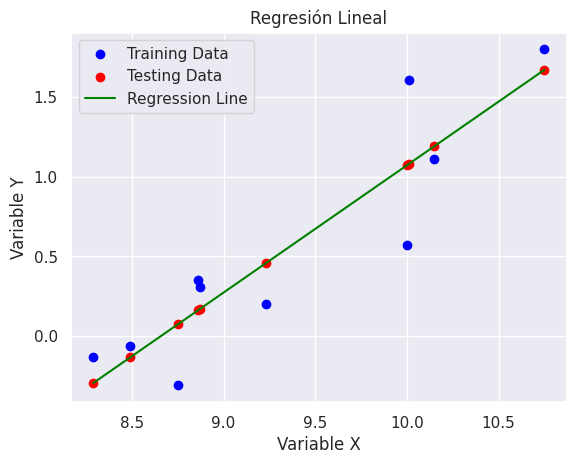

In [65]:
plt.scatter(xn, yn, color='blue', label='Training Data')

# Graficar los datos de prueba
plt.scatter(xn, y_pred, color='red', label='Testing Data')

# Graficar la línea de regresión
x_line = np.linspace(xn.min(), xn.max(), 100)
y_line = model.coef_ * x_line + model.intercept_
plt.plot(x_line, y_line, color='green', label='Regression Line')

# Configurar el título y las etiquetas de los ejes
plt.title('Regresión Lineal')
plt.xlabel('Variable X')
plt.ylabel('Variable Y')

# Mostrar la leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

In [66]:
from sklearn import linear_model

reg = linear_model.LinearRegression()

`fit(x_train, y_train)`: Ajusta el modelo de regresión lineal utilizando los datos de entrenamiento (`x_train` e `y_train`). Este método encuentra los coeficientes óptimos para la ecuación de regresión lineal basándose en los datos de entrenamiento.

In [67]:
reg.fit(x_train, y_train)

LinearRegression()

`score(x_train, y_train)`: Calcula el coeficiente de determinación $R^2$ del modelo utilizando los datos de entrenamiento (`x_train` e `y_train`). El coeficiente de determinación $R^2$ indica la proporción de la varianza explicada por el modelo y proporciona una medida de qué tan bien se ajusta el modelo a los datos de entrenamiento.


In [68]:
reg.score(x_train,y_train)

0.4630767924749212

`intercept_`: Devuelve el término de intercepción (también conocido como el coeficiente $b_0$ o el valor del eje $y$ cuando $x$ es 0) del modelo de regresión lineal. Este valor representa el punto en el que la línea de regresión intersecta el eje $y$.

In [69]:
reg.intercept_

np.float64(183939.94823194604)

`coef_`: Devuelve los coeficientes de regresión ($b_1, b_2, ..., b_n$) del modelo de regresión lineal. Estos coeficientes representan las pendientes de las variables predictoras ($x_1, x_2, ..., x_n$) en la ecuación de regresión lineal.

In [70]:
reg.coef_

array([ 27832.62225382, -56236.30859286,  44968.36459671, -57663.40202959,
        63355.85515381, 105976.94907833])

In [71]:
d = pd.DataFrame(reg.coef_, x.columns[:], columns=["Coeficient"])

In [72]:
d

,Coeficient
housing_median_age,27832.622254
total_rooms,-56236.308593
total_bedrooms,44968.364597
population,-57663.402030
households,63355.855154
median_income,105976.949078


In [73]:
y_predict = reg.predict(x_test)

In [74]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error , mean_squared_error

reg_score = r2_score(y_test, y_predict)
print('R^2:', reg_score)

mape = mean_absolute_percentage_error(y_test, y_predict)
print("Error porcentual absoluto medio de la regresión lineal:", mape*100, '%')

R^2: 0.4760729024785423
Error porcentual absoluto medio de la regresión lineal: 36.40854821178819 %


# Algoritmos alternativos de regresión

Existen muchos otros algoritmos alternativos para resolver problemas de regresion.

[Supervised learning](https://scikit-learn.org/stable/supervised_learning.html)

>Se llama **aprendizaje supervisado** cuando tenemos datos etiquetados, es decir que para las características o features contamos con las etiquetas o los datos de la variable que queremos predecir. De esta forma este aprendizaje se basa en enseñar al algoritmo de aprendizaje automatico a predecir la respuesta en función de las predictoras.

Ahora vamos a comparar otros enfoques de ajuste de modelos.


In [75]:
# Importamos metricas de ajuste de modelos de sklearn
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [76]:
results_test = pd.DataFrame(columns = ['Modelo',"root_mean_squared_error",'mean_absolute_error',"r2_score"])

In [77]:
results_test.head()

,Modelo,root_mean_squared_error,mean_absolute_error,r2_score


In [78]:
df.head(1)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0


## Decision Tree Regression

El árbol de decisión para las regresiones observa las **características de la base de datos de entrenamiento** y ajusta un modelo con **estructura de un árbol** para predecir datos desconocidos en el futuro, generando una salida numérica continua. Esto quiere decir que la salida/resultado no es discreta, es decir, no está representada sólo por un conjunto discreto y conocido de números o valores.

Ejemplo de salida discreta: Un modelo de predicción meteorológica que predice si lloverá o no un día determinado.

Ejemplo de salida continua: Un modelo de predicción de beneficios que indica el beneficio probable que puede generarse con la venta de un producto.

El árbol de decisión genera **regiones en las que los datos son homogéneos** en función de las características o variables de entrada en la base de datos. Estas regiones son definidas por preguntas binarias sucesivas que terminan dividiendo en múltiples **hojas** los subconjuntos de datos. Cada una de estas hojas tiene una determinada **predicción**, que es el **promedio de los datos que se encuentran agrupados dentro de esa hoja**. A la hora de realizar las particiones se **minimiza una métrica de ajuste**, que determina el límite numérico a partir del cual se dividen los datos. Es decir que el valor de la variable predictora que dividirá los datos, depende de **minimizar una métrica de error** sobre los datos de entrenamiento.

### Estructura

![](https://miro.medium.com/v2/resize:fit:1100/format:webp/0*12CT72krFYLtGFGx.png)

* Root Node (Nodo raiz): es el nodo superior del árbol. Representa el conjunto total de datos.
* Splitting (División): refiere a la división de un nodo (conjunto de datos) en 2 o más subnodos (subconjuntos de datos).
* Decision Node (Nodo de decisión): Son los nodos que posteriormente serán divididos en subnodos, i.e., un nodo con divisiones es llamado "nodo de decisión".
* Leaf / Terminal Node (Nodo terminal): Nodos que no tienen divisiones son llamados "hojas" o "nodos terminales".
* Branch / Sub-Tree: una subsección del árbol.
* Parent and Child Node (Nodo padre e hijo): un nodo que es dividido en subnodos se llama "padre" de los subnodos y estos se llaman "hijos".
* Pruning (Podado): remover subnodos de un nodo de decisión se llama "podado". Es usualmente usado en árboles de decisión para prevenir overfitting.



In [79]:
# Importamos el modelo
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [80]:
# Instanciamos el modelo
tree_mod = DecisionTreeRegressor()

In [81]:
# Entrenamos el modelo
tree_mod.fit(x_train, y_train)

DecisionTreeRegressor()

In [82]:
# Generamos predicciones
preds_tree = tree_mod.predict(x_test)

In [83]:
# Evaluamos el modelo
print(r2_score(y_test, preds_tree))
print(mean_squared_error(y_test, preds_tree))
print(mean_absolute_error(y_test, preds_tree))

0.053308109517610225
9058856664.19041
67348.90273972602


In [84]:
# Importamos estructura del arbol
from sklearn.tree import export_graphviz

# export the decision tree model to a tree_structure.dot file
# paste the contents of the file to webgraphviz.com
export_graphviz(tree_mod, out_file ='tree_structure.dot',
               feature_names =['housing_median_age',
       'total_rooms', 'total_bedrooms', 'population', 'households',
       'median_income'])

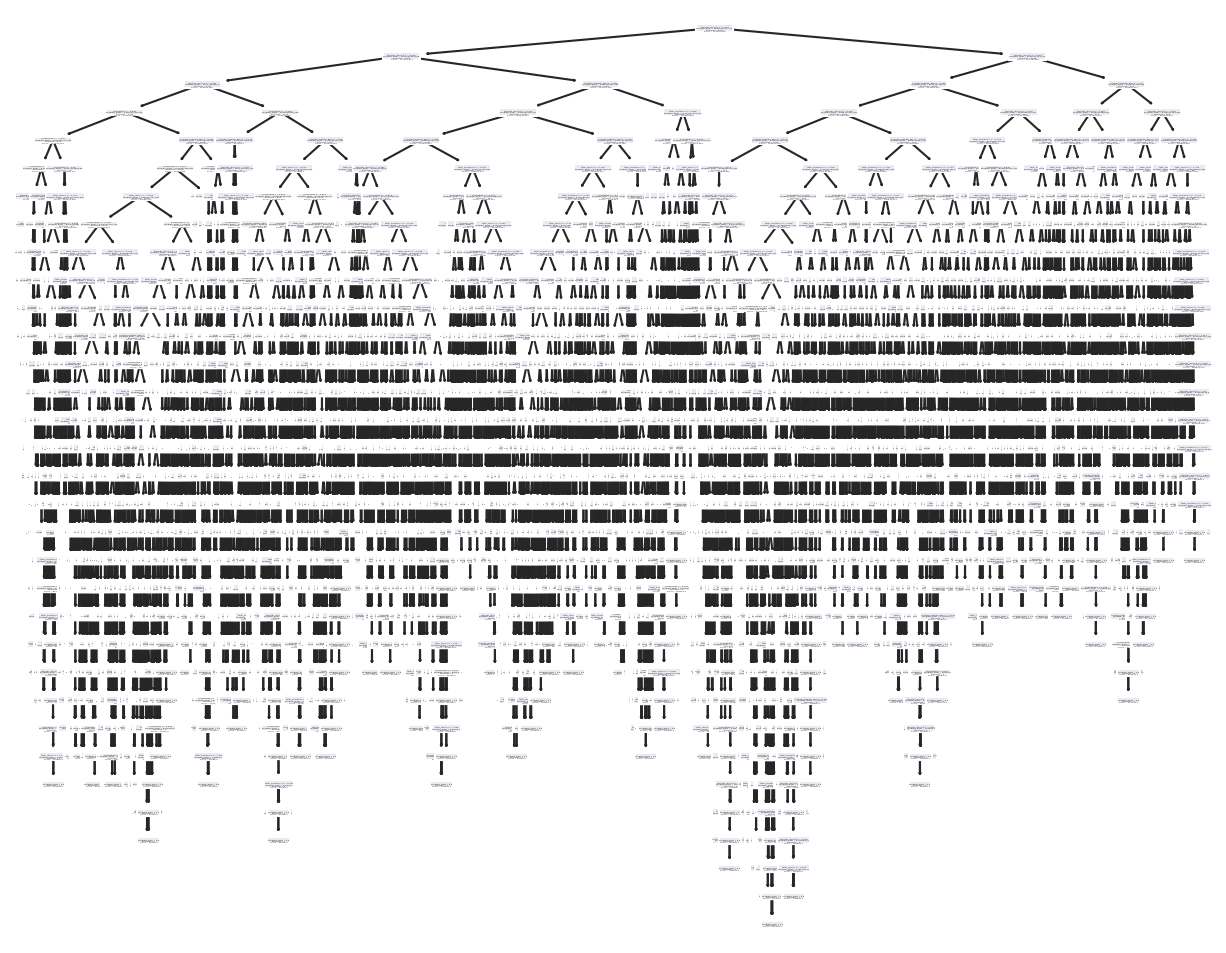

In [85]:
# Visualizamos el modelo
from sklearn.tree import plot_tree
plt.figure(figsize=(10,8), dpi=150)
plot_tree(tree_mod, feature_names=x.columns);

El árbol que acabamos de ajustar es muy largo y demora mucho su visualización así que incluyo una alternativa.

![](https://data36.com/wp-content/uploads/2022/02/regression_tree-973x706.png)

In [86]:
??RandomForestRegressor

Object `RandomForestRegressor` not found.


In [87]:
# Incluimos resultados en el dataframe para comparar los modelos
import warnings
warnings.filterwarnings("ignore")

resultado_parcial = {"Modelo": ["DecisionTreeRegressor"],
"root_mean_squared_error": [mean_squared_error(y_test, preds_tree)],
"mean_absolute_error": [mean_absolute_error(y_test, preds_tree)],
"r2_score": [r2_score(y_test, preds_tree)]
}
results_test = pd.concat([results_test, pd.DataFrame(resultado_parcial)])

resultado_parcial

{'Modelo': ['DecisionTreeRegressor'],
 'root_mean_squared_error': [9058856664.19041],
 'mean_absolute_error': [67348.90273972602],
 'r2_score': [0.053308109517610225]}

## Multiple linear regression

La clase pasada vimos el modelo de regresión lineal simple, ahora solo dejo material alternativo para consultar

[Material alternativo regresión lineal múltiple](https://www.scribbr.com/statistics/multiple-linear-regression/#:~:text=What%20is%20multiple%20linear%20regression,variables%20using%20a%20straight%20line.)

In [88]:
# Importamos el modelo
from sklearn.linear_model import LinearRegression

In [89]:
# Instanciamos el modelo
model = LinearRegression()

In [90]:
# Entrenamos el modelo
model.fit(x_train, y_train)

LinearRegression()

In [91]:
# Generamos predicciones
preds = model.predict(x_test)

In [92]:
# Evaluamos el modelo
print(r2_score(y_test, preds))
print(mean_squared_error(y_test, preds))
print(mean_absolute_error(y_test, preds))

0.4760729024785423
5013437346.034269
52228.72004240654


In [93]:
# Incluimos resultados en el dataframe para comparar los modelos

resultado_parcial = {"Modelo": ["LinearRegression"],
"root_mean_squared_error": [mean_squared_error(y_test, preds)],
"mean_absolute_error": [mean_absolute_error(y_test, preds)],
"r2_score": [r2_score(y_test, preds)]
}
results_test = pd.concat([results_test, pd.DataFrame(resultado_parcial)])

resultado_parcial

{'Modelo': ['LinearRegression'],
 'root_mean_squared_error': [5013437346.034269],
 'mean_absolute_error': [52228.72004240654],
 'r2_score': [0.4760729024785423]}

## Support Vector Regression

Las SVM o Support Vector Machines son uno de los algoritmos más populares y utilizados para tratar problemas de clasificación en el aprendizaje automático. Sin embargo, el uso de SVM en regresión no está muy bien documentado. Este algoritmo reconoce la presencia de no linealidad en los datos y proporciona un modelo de predicción competente.

El algoritmo de regresión SVM se denomina regresión de vectores de soporte o SVR. Antes de empezar con el algoritmo, es necesario que tengamos una intuición de lo que es realmente una máquina de vectores soporte.

### Support Vector Machine (Máquina de vectores soporte)

En el aprendizaje automático, las máquinas de vectores de soporte son modelos de aprendizaje supervisado con algoritmos de aprendizaje asociados que analizan los datos utilizados para la clasificación y el análisis de regresión. En la regresión por vectores de soporte, la línea recta que debe ajustarse a los datos se denomina hiperplano.

El objetivo de un algoritmo de máquina de vectores soporte es **encontrar un hiperplano en un espacio n-dimensional** que clasifique claramente los puntos de datos. Los puntos de datos a ambos lados del hiperplano que están más cerca del hiperplano se denominan **vectores de soporte**. Éstos influyen en la posición y orientación del hiperplano y, por tanto, ayudan a construir la SVM.

### Características SVR

Ahora que tenemos una intuición de lo que es una máquina de vectores de soporte, vamos a echar un vistazo a los distintos hiperparámetros que se utilizan en la regresión de vectores de soporte. Algunos de los parámetros clave utilizados son los que se mencionan a continuación:

**1. Hiperplano:**

Los hiperplanos son límites de decisión que se utilizan para predecir la salida continua. Los puntos de datos a cada lado del hiperplano que están más cerca del hiperplano se llaman Vectores de Soporte. Estos se utilizan para trazar la línea requerida que muestra la salida predicha del algoritmo.

**2. Kernel:**
Un kernel es un conjunto de funciones matemáticas que toman los datos como entrada y los transforman en la forma requerida. Generalmente se utilizan para encontrar un hiperplano en el espacio dimensional superior.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*yVbqz60gtXoMwhdLZ34hfQ.png)

Los kernels más utilizados son Lineal, No Lineal, Polinómico, Función de Base Radial (RBF) y Sigmoide. Por defecto, se utiliza RBF como kernel. Cada uno de estos kernels se utiliza en función del conjunto de datos.

**3. Boundary Lines (Líneas límite):**
Son las dos líneas que se dibujan alrededor del hiperplano a una distancia de ε (épsilon). Se utiliza para crear un margen entre los puntos de datos.

### Regresión de vectores de soporte

La regresión de vectores de soporte es un algoritmo de aprendizaje supervisado que se utiliza para predecir valores continuos. La regresión de vectores de soporte utiliza el mismo principio que las SVM. La idea básica de SVR es **encontrar la línea de mejor ajuste**. En SVR, la línea de mejor ajuste es el hiperplano que tiene el máximo número de puntos.

![](https://miro.medium.com/v2/resize:fit:1100/1*Gr72C6I-u0ZWdgBxI47JBw.gif)

A diferencia de otros modelos de Regresión que intentan minimizar el error entre el valor real y el predicho, el SVR intenta **ajustar el mejor hiperplano dentro de un valor umbral**. **El valor umbral (margen) es la distancia entre el hiperplano y la línea límite (definida por los vectores de soporte)**. La complejidad del tiempo de ajuste de SVR es más que cuadrática con el número de muestras, lo que hace que sea difícil de escalar a conjuntos de datos con más de un par de 10000 muestras.

Para grandes conjuntos de datos, se utiliza SVR lineal o SGD Regressor. El SVR lineal ofrece una aplicación más rápida que el SVR, pero sólo tiene en cuenta el kernel lineal. El modelo producido por la regresión de vectores de soporte sólo depende de un subconjunto de los datos de entrenamiento, porque la función de coste ignora las muestras cuya predicción se acerca a su objetivo.



In [94]:
# Importamos el modelo
from sklearn.svm import SVR

In [95]:
# Instanciamos el modelo
model = SVR()

In [96]:
# Entrenamos el modelo
model.fit(x_train, y_train)

SVR()

In [97]:
# Generamos predicciones
preds = model.predict(x_test)

In [98]:
# Evaluamos el modelo
print(r2_score(y_test, preds))
print(mean_squared_error(y_test, preds))
print(mean_absolute_error(y_test, preds))

-0.030903920737760382
9864678198.264341
74130.64747016659


In [99]:
# Incluimos resultados en el dataframe para comparar los modelos

resultado_parcial = {
    "Modelo": ["SVR"],
    "root_mean_squared_error": [mean_squared_error(y_test, preds)],
    "mean_absolute_error": [mean_absolute_error(y_test, preds)],
    "r2_score": [r2_score(y_test, preds)]
    }
results_test = pd.concat([results_test, pd.DataFrame(resultado_parcial)])

resultado_parcial

{'Modelo': ['SVR'],
 'root_mean_squared_error': [9864678198.264341],
 'mean_absolute_error': [74130.64747016659],
 'r2_score': [-0.030903920737760382]}

In [100]:
results_test.head()

,Modelo,root_mean_squared_error,mean_absolute_error,r2_score
0,DecisionTreeRegressor,9.058857e+09,67348.902740,0.053308
0,LinearRegression,5.013437e+09,52228.720042,0.476073
0,SVR,9.864678e+09,74130.647470,-0.030904


## KNeighborsRegressor

K-nearest neighbors (KNN) es un tipo de algoritmo de aprendizaje supervisado que se utiliza tanto para la regresión como para la clasificación. KNN intenta predecir la clase correcta para los datos de prueba calculando la distancia entre los datos de prueba y todos los puntos de entrenamiento. A continuación, **selecciona el número K de puntos que está más cerca de los datos de prueba**. El algoritmo KNN calcula la probabilidad de que los datos de prueba pertenezcan a las clases de 'K' datos de entrenamiento y se seleccionará la clase que tenga la probabilidad más alta. En el caso de la regresión, el valor es la **media de los 'K' puntos de entrenamiento seleccionados**.

Veamos el siguiente ejemplo para comprenderlo mejor

![](https://miro.medium.com/v2/resize:fit:1100/format:webp/0*34SajbTO2C5Lvigs.png)

### ¿Cómo funciona K-NN?

El funcionamiento de K-NN puede explicarse a partir del siguiente algoritmo:

* Paso 1: Seleccionar el número **K** de vecinos

* Paso 2: Calcular la **distancia** (en principio, euclídea) de K vecinos.

* Paso 3: Tomar los **K vecinos más cercanos** según la distancia calculada.

* Paso 4: Entre estos k vecinos, contar el número de puntos de datos de cada categoría.

* Paso 5: Asignar los nuevos puntos de datos a la categoría cuyo número de vecinos sea máximo.

Supongamos que tenemos un nuevo punto de datos y necesitamos ponerlo en la categoría requerida. Consideremos la siguiente imagen:

![](https://miro.medium.com/v2/resize:fit:640/format:webp/0*ScrTqSXzBTRNnh5q.png)

* En primer lugar, elegiremos el número de vecinos, por lo que escogeremos el k=5.

* A continuación, calcularemos la distancia euclídea entre los puntos de datos. La distancia euclídea es la distancia entre dos puntos, que ya hemos estudiado en geometría. Se puede calcular como:

![](https://miro.medium.com/v2/resize:fit:640/format:webp/0*p10az8ZLEOf_w5kx.png)

$d(A, B) = \sqrt{(X_2 - X_1)^2 + (Y_2 - Y_1)^2}$

* Calculando la distancia euclidiana obtenemos los vecinos más próximos, como tres vecinos más próximos en la categoría A y dos vecinos más próximos en la categoría B. Consideremos la imagen siguiente:

![](https://miro.medium.com/v2/resize:fit:640/format:webp/0*zCnwFe1zL2tGN5oi.png)

* Como podemos ver los 3 vecinos más cercanos son de la categoría A, por lo tanto este nuevo punto de datos debe pertenecer a la categoría A.

* En el problema de regresión el valor predicho para el dato no conocido surge de la media del valor de la variable respuesta para los 5 vecinos más cercanos.

### ¿Cómo elegir un valor K?

El valor K indica el número de vecinos más cercanos. Tenemos que calcular las distancias entre los puntos de prueba y los puntos de las etiquetas entrenadas. Actualizar las métricas de distancia en cada iteración es costoso desde el punto de vista computacional, y por eso KNN es un algoritmo de aprendizaje perezoso.

![](https://miro.medium.com/v2/resize:fit:640/format:webp/0*KxkMe86skK9QRcJu.jpg)

Como se puede comprobar en la imagen anterior, si procedemos con **K=3, entonces predecimos que la entrada de prueba pertenece a la clase B, y si continuamos con K=7, entonces predecimos que la entrada de prueba pertenece a la clase A.**

Así es como se puede imaginar que el valor K tiene un poderoso efecto en el rendimiento KNN.

Entonces,

#### ¿cómo seleccionar el valor óptimo de K?

* No existen métodos estadísticos predefinidos para encontrar el valor más favorable de K.

* Elegir un valor pequeño de K conduce a límites de decisión inestables.

* El valor sustancial de K es mejor para la clasificación, ya que conduce a suavizar los límites de decisión.

* Una opción es obtener un gráfico entre la tasa de error y K indicando valores en un intervalo definido. A continuación, elegir el valor K que tenga una tasa de error mínima.

### Cálculo de la distancia

El primer paso es calcular la distancia entre el nuevo punto y cada punto de entrenamiento. Existen varios métodos para calcular esta distancia, de los cuales los más conocidos son: la distancia euclidiana, la distancia de Manhattan (para las continuas) y la distancia de Hamming (para las categóricas).

**Distancia euclídea:** La distancia euclídea se calcula como la raíz cuadrada de la suma de las diferencias al cuadrado entre un punto nuevo (x) y un punto existente (y).

**Distancia Manhattan:** Es la distancia entre vectores reales utilizando la suma de su diferencia absoluta.

![](https://miro.medium.com/v2/resize:fit:600/format:webp/0*cc0YOp9aRJzFpVHa.png)

**Distancia de Hamming:** Se utiliza para variables categóricas. Si el valor (x) y el valor (y) son iguales, la distancia D será igual a 0 . En caso contrario D=1.

![](https://miro.medium.com/v2/resize:fit:432/format:webp/0*qxYGj_pO6Qj_coZ_.png)

In [101]:
# Importamos el modelo
from sklearn.neighbors import KNeighborsRegressor

In [102]:
# Instanciamos el modelo
model = KNeighborsRegressor()

In [103]:
# Entrenamos el modelo
model.fit(x_train, y_train)

KNeighborsRegressor()

In [104]:
# Generamos predicciones
preds = model.predict(x_test)

In [105]:
# Evaluamos el modelo
print(r2_score(y_test, preds))
print(mean_squared_error(y_test, preds))
print(mean_absolute_error(y_test, preds))

0.48252237410874954
4951722611.129293
50595.09873972602


In [106]:
# Incluimos resultados en el dataframe para comparar los modelos

resultado_parcial = {"Modelo": ["KNeighborsRegressor"],
"root_mean_squared_error": [mean_squared_error(y_test, preds)],
"mean_absolute_error": [mean_absolute_error(y_test, preds)],
"r2_score": [r2_score(y_test, preds)]
}
results_test = pd.concat([results_test, pd.DataFrame(resultado_parcial)])

resultado_parcial

{'Modelo': ['KNeighborsRegressor'],
 'root_mean_squared_error': [4951722611.129293],
 'mean_absolute_error': [50595.09873972602],
 'r2_score': [0.48252237410874954]}

In [107]:
results_test.head()

,Modelo,root_mean_squared_error,mean_absolute_error,r2_score
0,DecisionTreeRegressor,9.058857e+09,67348.902740,0.053308
0,LinearRegression,5.013437e+09,52228.720042,0.476073
0,SVR,9.864678e+09,74130.647470,-0.030904
0,KNeighborsRegressor,4.951723e+09,50595.098740,0.482522


# Random Forest Regressor

Random Forest Regressor es un algoritmo de aprendizaje supervisado y una técnica de bagging que utiliza un método de aprendizaje de enseamble para la regresión en el aprendizaje automático. Los árboles de los bosques aleatorios se ejecutan en paralelo, lo que significa que no hay interacción entre ellos mientras se construyen.

![](https://builtin.com/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/2_random-forest-python.png)

### Ejemplo de random forest

Por ejemplo, veamos los **nueve clasificadores de árbol** de decisión que aparecen a continuación:

![](https://builtin.com/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/3_random-forest-python.png)

Podemos agregar estos clasificadores de árbol de decisión en un conjunto de **bosque aleatorio** que combine sus entradas. Piense en los ejes horizontal y vertical de los resultados del árbol de decisión como las características x1 y x2. Para determinados valores de cada característica, el árbol de decisión produce una clasificación de azul, verde, rojo, etc.

Los resultados anteriores se agregan, mediante votaciones de modelos o promediado, en un único modelo conjunto que acaba superando los resultados de cualquier árbol de decisión individual.

A continuación podemos ver el resultado agregado de los nueve clasificadores de árboles de decisión:

![](https://builtin.com/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/4_random-forest-python.png)

### Definiciones de regresión de Random Forest

#### Ensemble learning

Un **método ensemble es una técnica que combina las predicciones de varios algoritmos de aprendizaje automático para realizar predicciones más precisas que cualquier modelo individual**. Un modelo compuesto por varios modelos se denomina modelo ensemble.

![](https://builtin.com/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/1_random-forest-python.png)

#### Ventajas de la regresión Random Forest

* Random Forest es uno de los algoritmos de aprendizaje más precisos que existen. Para muchos conjuntos de datos, produce un clasificador de alta precisión.

* Se ejecuta eficientemente en grandes bases de datos.

* Puede manejar miles de variables de entrada sin eliminación de variables.

* Proporciona estimaciones sobre qué variables son importantes en la clasificación.

* Genera una estimación interna insesgada del error de generalización a medida que avanza la construcción del bosque.

* Dispone de un método eficaz para estimar los datos que faltan y mantiene la precisión cuando falta una gran proporción de los datos.

#### Problemas de los árboles de decisión

Los árboles de decisión son sensibles a los datos específicos con los que se entrenan. Si se cambian los datos de entrenamiento, el árbol de decisión resultante puede ser muy diferente y, a su vez, las predicciones pueden ser distintas.

Además, el entrenamiento de los árboles de decisión es costoso desde el punto de vista informático, conlleva un gran riesgo de sobreajuste y tiende a encontrar óptimos locales porque no puede volver atrás después de haber realizado una división.

Para subsanar estas deficiencias, recurrimos a los bosques aleatorios, que ilustran la potencia de combinar varios árboles de decisión en un solo modelo.

#### Desventajas de la regresión de bosques aleatorios

* Se ha observado que los bosques aleatorios se ajustan en exceso a algunos conjuntos de datos con tareas de clasificación/regresión ruidosas.

* Para datos que incluyen variables categóricas con diferentes números de niveles, los bosques aleatorios están sesgados a favor de los atributos con más niveles. Por lo tanto, las puntuaciones de importancia de las variables de los bosques aleatorios no son fiables para este tipo de datos.

In [108]:
# Importamos el modelo
from sklearn.ensemble import RandomForestRegressor

In [109]:
# Instanciamos el modelo
model = RandomForestRegressor()

In [110]:
# Entrenamos el modelo
model.fit(x_train, y_train)

RandomForestRegressor()

In [111]:
# Generamos predicciones
preds = model.predict(x_test)

In [112]:
# Evaluamos el modelo
print(r2_score(y_test, preds))
print(mean_squared_error(y_test, preds))
print(mean_absolute_error(y_test, preds))

0.5254445734676976
4541001809.975723
48395.89970684932


In [113]:
# Incluimos resultados en el dataframe para comparar los modelos

resultado_parcial = {"Modelo": ["RandomForestRegressor"],
"root_mean_squared_error": [mean_squared_error(y_test, preds)],
"mean_absolute_error": [mean_absolute_error(y_test, preds)],
"r2_score": [r2_score(y_test, preds)]
}
results_test = pd.concat([results_test, pd.DataFrame(resultado_parcial)])

resultado_parcial

{'Modelo': ['RandomForestRegressor'],
 'root_mean_squared_error': [4541001809.975723],
 'mean_absolute_error': [48395.89970684932],
 'r2_score': [0.5254445734676976]}

#### Hiperarámetros

* `n_estimators` — número de árboles de decisión que se entrenarán para construir el modelo.
* `criterion` — criterio (loss function) usado para determinar los resultados del modelo. Se pueden seleccionar desde funciones de loss como mean squared error (MSE) y mean absolute error (MAE). El default es MSE.
* `max_depth` — profundidad máxima posible de cada árbol.
* `max_features` — máximo número de atributos que el modelo va a considerar.
* `bootstrap` — el valor por default es True, significando que el modelo sigue los principios de bootstrapping
* `max_samples` — Este parámetro asume bootstrapping seteado en True, sino no aplica. En caso de True, establece el tamaño más grande de cada sample para cada árbol.
* Otros parámetros son `min_samples_split`, `min_samples_leaf`, `n_jobs`, etc..

# Descenso por gradiente

El descenso de gradiente es un **algoritmo de optimización** que se utiliza habitualmente para **entrenar modelos de aprendizaje automático y redes neuronales**.  Los datos de entrenamiento ayudan a estos modelos a aprender con el tiempo, y la **función de costo** dentro del descenso de gradiente actúa específicamente como un barómetro, midiendo su precisión con cada iteración de actualizaciones de parámetros. Hasta que la función se acerque o sea igual a cero, **el modelo seguirá ajustando sus parámetros para producir el menor error posible**. Una vez que los modelos de aprendizaje automático se han optimizado en cuanto a precisión, pueden convertirse en potentes herramientas para aplicaciones de inteligencia artificial (IA) e informática.

#### ¿Cómo funciona el descenso por gradiente?


Antes de sumergirnos en el descenso de gradiente, puede ser útil repasar algunos conceptos de la regresión lineal. Por un lado, recordemos fórmula para parametrizar una recta: $y = mx + b$, donde $m$ representa la pendiente y $b$ es la intercección con el eje $y$.

Por otro, recordemos cuando trazamos un diagrama de dispersión en estadística y encontramos la línea de mejor ajuste, requería calcular el error entre la salida real y la salida predicha ($\hat y$) utilizando la fórmula del error cuadrático medio. **El algoritmo de descenso de gradiente se comporta de forma similar, pero se basa en una función convexa.**

El punto de partida es un punto arbitrario para evaluar el rendimiento. A partir de ese punto de partida, encontraremos la derivada (o pendiente), y a partir de ahí, podemos utilizar una línea tangente para observar la inclinación de la pendiente. **La pendiente informará de las actualizaciones de los parámetros, es decir, las ponderaciones y el sesgo. La pendiente en el punto de partida será más pronunciada, pero a medida que se generan nuevos parámetros, la pendiente debería reducirse gradualmente hasta alcanzar el punto más bajo de la curva, conocido como punto de convergencia.**  

De forma similar a la búsqueda de la línea de mejor ajuste en la regresión lineal, **el objetivo del descenso de gradiente es minimizar la función de coste, o el error entre la predicción y el valor real de $y$**. Para ello, se necesitan dos puntos de datos: **una dirección y una tasa de aprendizaje.** Estos factores determinan los cálculos de las derivadas parciales de las iteraciones futuras, lo que permite llegar gradualmente al **mínimo local o global (es decir, al punto de convergencia).**

* **La tasa de aprendizaje** (también denominada tamaño del paso o alfa) **es el tamaño de los pasos que se dan para alcanzar el mínimo**. Suele ser un valor pequeño, y se evalúa y actualiza en función del comportamiento de la función de coste. Una tasa de aprendizaje alta da lugar a pasos más grandes, pero se corre el riesgo de sobrepasar el mínimo. Por el contrario, una tasa de aprendizaje baja da lugar a pasos pequeños. Aunque tiene la ventaja de una mayor precisión, el número de iteraciones compromete la eficacia global, ya que se necesita más tiempo y cálculos para alcanzar el mínimo.

* **La función de coste** (o pérdida) mide la diferencia, o error, entre la $y$ real y la $y$ predicha en su posición actual. Esto mejora la eficacia del modelo de aprendizaje automático al proporcionar información al modelo para que pueda ajustar los parámetros para minimizar el error y encontrar el mínimo local o global. Se itera continuamente, moviéndose a lo largo de la dirección de descenso más pronunciado (o el gradiente negativo) hasta que la función de coste está cerca o en cero. En este punto, el modelo dejará de aprender. Además, aunque los términos función de coste y función de pérdida se consideran sinónimos, existe una ligera diferencia entre ellos. Cabe señalar que una función de pérdida se refiere al error de un ejemplo de entrenamiento, mientras que una función de coste calcula el error medio de todo un conjunto de entrenamiento.

![](https://www.ibm.com/content/dam/connectedassets-adobe-cms/worldwide-content/cdp/cf/ul/g/c2/0f/ICLH_Diagram_Batch_03_21-AI-ML-GradientDescent.component.simple-narrative-m.ts=1680733164134.png/content/adobe-cms/us/en/topics/gradient-descent/jcr:content/root/table_of_contents/body/simple_narrative_1771421240/image)

![](https://saugatbhattarai.com.np/wp-content/uploads/2018/06/gradient-descent-1.jpg)

![](https://zitaoshen.rbind.io/project/optimization/1-min-of-machine-learning-gradient-decent/featured_hubf6ae7b9a0510d717632b017746fdfc1_374655_720x0_resize_lanczos_2.png)

[Pasos de descenso por el gradiente](https://towardsdatascience.com/gradient-descent-algorithm-a-deep-dive-cf04e8115f21)

En resumen, **los pasos del Descenso por Gradiente son**:

1. elegir un punto inicial (initialización)

2. cálculo del **gradiente** en ese punto

3. hacer un paso escalonado en la dirección opuesta a la del gradiente (objetivo: minimizar)

4. Repetir 2 y 3 hasta que uno de los criterios siguientes ocurra:

  * máximo número de iteraciones alcanzado

  * El *step size* es menor que la tolerancia (debido al scaling o un gradiente chico).

**Intuitivamente, el gradiente es la pendiente de una curva en un punto dado en una dirección determinada.**

* En el caso de una función **univariante**, es simplemente la primera derivada en un punto seleccionado.

* En el caso de una función **multivariante**, es un vector de derivadas en cada dirección principal (a lo largo de ejes variables). Como sólo nos interesa la pendiente a lo largo de un eje y no nos importan los demás, estas **derivadas se denominan derivadas parciales**.

___
Un gradiente para una función n-dimensional $f(x)$ en un punto dado p se define como sigue:

$\nabla f(p)=
\begin{bmatrix}
\frac{\partial f}{\partial x_1}(p)\\
\vdots\\
\frac{\partial f}{\partial x_n}(p)
\end{bmatrix}$


El triángulo invertido es el llamado símbolo nabla. Para entender mejor cómo calcularlo hagamos a continuación un cálculo manual para una función bidimensional ejemplar.

$f(x)=0.5x^2+y^2$

![](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*fWc_cUNDEn4LpS6aissyXA.jpeg)

Supongamos que estamos interesados en un gradiente en el punto $p=(10,10)$:

$\frac{\partial f(x,y)}{\partial x} = x$, $\frac{\partial f(x,y)}{\partial y} = 2y$

De esta forma:

$\nabla f(x,y)=
\begin{bmatrix}
x\\
2y
\end{bmatrix}$

$\nabla f(10,10)=
\begin{bmatrix}
10\\
20
\end{bmatrix}$

# Gradient boosting


Gradient Boosting es una metodología de aprendizaje automático en la que se utiliza un conjunto de aprendices débiles para mejorar el rendimiento del modelo en términos de eficacia, precisión e interpretabilidad. Estos aprendices se definen por tener un rendimiento mejor que el azar. Estos modelos suelen ser árboles de decisión y sus resultados se combinan para obtener mejores resultados globales.

### Boosting en regresión

![](https://www.researchgate.net/publication/345327934/figure/fig3/AS:1022810793209856@1620868504478/Flow-chart-of-XGBoost_W640.jpg)

El **gradient boosting** consta de tres elementos:

* Una **función de pérdida** que debe optimizarse.

* Un **aprendiz débil** para hacer predicciones.

* Un **modelo aditivo** que añada aprendices débiles para minimizar la función de pérdida.

**1. Función de pérdida**

La función de pérdida utilizada depende del tipo de problema que se esté resolviendo.

Debe ser diferenciable, pero se admiten muchas funciones de pérdida estándar y se puede definir la propia.

Por ejemplo, la regresión puede utilizar un error al cuadrado y la clasificación puede utilizar una pérdida logarítmica.

Una ventaja del marco de trabajo del refuerzo de gradiente es que no es necesario derivar un nuevo algoritmo de refuerzo para cada función de pérdida que se quiera utilizar, sino que es un marco de trabajo lo suficientemente genérico como para que se pueda utilizar cualquier función de pérdida diferenciable.

**2. Aprendiz débil**

Los árboles de decisión se utilizan como aprendiz débil en la potenciación por gradiente.

En concreto, se utilizan árboles de regresión que arrojan valores reales para las divisiones y cuyos resultados pueden sumarse, lo que permite añadir los resultados de modelos posteriores y "corregir" los residuos en las predicciones.

Los árboles se construyen de forma golosa, eligiendo los mejores puntos de división basándose en puntuaciones de pureza como Gini o para minimizar la pérdida.

Al principio, como en el caso de AdaBoost, se utilizaban árboles de decisión muy cortos que sólo tenían una única división, llamada tocón de decisión. Ahora se pueden utilizar árboles más grandes, generalmente con entre 4 y 8 niveles.

Es habitual restringir los aprendices débiles de formas específicas, como un número máximo de capas, nodos, divisiones o nodos hoja.

Así se garantiza que los aprendices sigan siendo débiles, pero que puedan construirse de forma golosa.

**3. Modelo aditivo**

Los árboles se añaden de uno en uno, y los árboles existentes en el modelo no se modifican.

Se utiliza un procedimiento de descenso gradiente para minimizar la pérdida al añadir árboles.

Tradicionalmente, el descenso de gradiente se utiliza para minimizar un conjunto de parámetros, como los coeficientes de una ecuación de regresión o los pesos de una red neuronal. Tras calcular el error o la pérdida, los pesos se actualizan para minimizar ese error.

En lugar de parámetros, tenemos submodelos de aprendizaje débil o, más concretamente, árboles de decisión. Tras calcular la pérdida, para realizar el procedimiento de descenso gradiente, debemos añadir un árbol al modelo que reduzca la pérdida (es decir, que siga el gradiente). Para ello, parametrizamos el árbol, luego modificamos los parámetros del árbol y nos movemos en la dirección correcta (reduciendo la pérdida residual). Generalmente, este enfoque se denomina descenso de gradiente funcional o descenso de gradiente con funciones.

Una forma de producir una combinación ponderada de clasificadores que optimice [el coste] es mediante el descenso gradiente en el espacio de funciones: [Algoritmos de refuerzo como descenso gradiente en el espacio de funciones, 1999](https://proceedings.neurips.cc/paper_files/paper/1999/file/96a93ba89a5b5c6c226e49b88973f46e-Paper.pdf)

El resultado del nuevo árbol se añade al resultado de la secuencia de árboles existente para corregir o mejorar el resultado final del modelo. Se añade un número fijo de árboles o se detiene el entrenamiento una vez que la pérdida alcanza un nivel aceptable o deja de mejorar en un conjunto de datos de validación externo.

### XGBOOST


Extreme Gradient Boosting (XGBoost) es una biblioteca de código abierto que proporciona una implementación eficiente y eficaz del algoritmo gradient boosting.

Poco después de su desarrollo y publicación inicial, XGBoost se convirtió en el método de referencia y, a menudo, en el componente clave de las soluciones ganadoras para una serie de problemas en competiciones de aprendizaje automático.

### Extreme Gradient Boosting


Gradient Boosting hace referencia a una clase de algoritmos de aprendizaje automático de ensamble que pueden utilizarse para problemas de modelado predictivo de clasificación o regresión.

Los modelos se ajustan utilizando cualquier función de pérdida diferenciable arbitraria y un algoritmo de optimización de descenso de gradiente. De ahí el nombre de la técnica, **"gradient boosting"**, ya que el gradiente de pérdida se minimiza a medida que se ajusta el modelo, de forma muy parecida a una red neuronal.

Para más información, ver el tutorial: [A Gentle Introduction to the Gradient Boosting Algorithm for Machine Learning](https://machinelearningmastery.com/gentle-introduction-gradient-boosting-algorithm-machine-learning/).

Extreme Gradient Boosting, o **XGBoost** para abreviar, es una eficiente implementación de código abierto del algoritmo de refuerzo de gradiente. Como tal, XGBoost es un algoritmo, un proyecto de código abierto y una biblioteca Python.
Fue desarrollado inicialmente por Tianqi Chen y descrito por Chen y Carlos Guestrin en su artículo de 2016 titulado "[XGBoost: A Scalable Tree Boosting System](https://arxiv.org/abs/1603.02754)".

Está diseñado para ser **computacionalmente eficiente** (por ejemplo, rápido de ejecutar) y altamente eficaz, quizás más eficaz que otras implementaciones de código abierto.

Las dos razones principales para utilizar XGBoost son:
 * velocidad de ejecución
 * rendimiento del modelo.

XGBoost domina los conjuntos de datos estructurados o tabulares en problemas de modelado predictivo de clasificación y regresión. La prueba es que es el algoritmo al que recurren los ganadores de concursos en la plataforma competitiva de ciencia de datos Kaggle. "Entre las 29 soluciones ganadoras del desafío 3 publicadas en el blog de Kaggle durante 2015, 17 soluciones utilizaron XGBoost. [...] El éxito del sistema también quedó patente en la KDDCup 2015, donde todos los equipos ganadores del top-10 utilizaron XGBoost." [XGBoost: A Scalable Tree Boosting System, 2016.](https://arxiv.org/abs/1603.02754)

#### Hiperparámetros más frecuentemente configurados

* `n_estimators`: número de árboles en el modelo. Usualmente es incrementado hasta que no haya mejorías.
* `max_depth`: Profundidad máxima de cada árbol. Usualmente toma valores entre 1 y 10.
* `eta`: Learning rate usado para pesar a cada modelo. Usualmente es un valor pequeño como 0.3, 0.1, 0.01, o más chico.
* `subsample`: proporción de samples (filas) usados en cada árbol, seteado entre 0 y 1.
* `colsample_bytree`: proporción de atributos (columnas) usado en cada árbol seteado también entre 0 y 1.

In [114]:
# Importamos el modelo
from xgboost import XGBRegressor

In [115]:
# Instanciamos el modelo
model = XGBRegressor()

In [116]:
# Entrenamos el modelo
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [117]:
# Generamos predicciones
preds = model.predict(x_test)

In [118]:
# Evaluamos el modelo
print(r2_score(y_test, preds))
print(mean_squared_error(y_test, preds))
print(mean_absolute_error(y_test, preds))

0.5028678351472036
4757037711.884713
49878.0843942637


In [119]:
# Incluimos resultados en el dataframe para comparar los modelos

resultado_parcial = {"Modelo": ["XGBRegressor"],
"root_mean_squared_error": [mean_squared_error(y_test, preds)],
"mean_absolute_error": [mean_absolute_error(y_test, preds)],
"r2_score": [r2_score(y_test, preds)]
}
results_test = pd.concat([results_test, pd.DataFrame(resultado_parcial)])

resultado_parcial

{'Modelo': ['XGBRegressor'],
 'root_mean_squared_error': [4757037711.884713],
 'mean_absolute_error': [49878.0843942637],
 'r2_score': [0.5028678351472036]}

## LightGBM


Similar a XGBoost, LightGBM (de Microsoft) es un marco distribuido de alto rendimiento que utiliza árboles de decisión para tareas de clasificación y regresión.

Las ventajas son las siguientes

* Mayor velocidad de entrenamiento y precisión gracias a que LightGBM es un algoritmo basado en histogramas que realiza bucketing de valores (también requiere menos memoria).

* También es compatible con conjuntos de datos grandes y complejos, pero es mucho más rápido durante el entrenamiento

* Compatible con el aprendizaje paralelo y el aprendizaje en la GPU

A diferencia del crecimiento por niveles (horizontal) de XGBoost, LightGBM lleva a cabo un crecimiento por hojas (vertical) que reduce más las pérdidas y, a su vez, aumenta la precisión al tiempo que es más rápido. Sin embargo, esto también puede dar lugar a un exceso de ajuste en los datos de entrenamiento, lo que puede solucionarse utilizando el parámetro de profundidad máxima, que especifica dónde se producirá la división. Por lo tanto, XGBoost es capaz de construir modelos más robustos que LightGBM.

### Diferencias estructurales entre XGBoost y LightGBM



Por lo que hemos visto hasta ahora, parece que ambos algoritmos funcionan bastante bien por sí solos. LightGBM es significativamente más rápido que XGBoost, pero ofrece un rendimiento casi equivalente. Cabe preguntarse cuáles son exactamente las diferencias entre LightGBM y XGBoost.

Algunas diferencias fundamentales entre los dos algoritmos son: crecimiento de la hoja, manejo de características categóricas, manejo de valores perdidos, y los respectivos métodos de importancia de las características.

* XGBoost

![](https://i0.wp.com/neptune.ai/wp-content/uploads/2022/10/XGBoost-vs-LightGBM-tree-growth.png?ssl=1)

* LightGBM

![](https://i0.wp.com/neptune.ai/wp-content/uploads/2022/10/XGBoost-vs-LightGBM-tree-growth-2.png?ssl=1)

[Mayor explicación de las diferencias entre los algoritmos](https://neptune.ai/blog/xgboost-vs-lightgbm)

In [120]:
# Importamos el modelo
from lightgbm import LGBMRegressor

In [121]:
# Instanciamos el modelo
model = LGBMRegressor()

In [122]:
# Entrenamos el modelo
model.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000720 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1322
[LightGBM] [Info] Number of data points in the train set: 8516, number of used features: 6
[LightGBM] [Info] Start training from score 182241.244598


LGBMRegressor()

In [123]:
# Generamos predicciones
preds = model.predict(x_test)

In [124]:
# Evaluamos el modelo
print(r2_score(y_test, preds))
print(mean_squared_error(y_test, preds))
print(mean_absolute_error(y_test, preds))

0.5476862571331449
4328172032.599174
47625.98767505465


In [125]:
# Incluimos resultados en el dataframe para comparar los modelos

resultado_parcial = {"Modelo": ["LGBMRegressor"],
"root_mean_squared_error": [mean_squared_error(y_test, preds)],
"mean_absolute_error": [mean_absolute_error(y_test, preds)],
"r2_score": [r2_score(y_test, preds)]
}
results_test = pd.concat([results_test, pd.DataFrame(resultado_parcial)])

resultado_parcial

{'Modelo': ['LGBMRegressor'],
 'root_mean_squared_error': [4328172032.599174],
 'mean_absolute_error': [47625.98767505465],
 'r2_score': [0.5476862571331449]}

## Comparación de algoritmos

In [126]:
results_test.head(30)

,Modelo,root_mean_squared_error,mean_absolute_error,r2_score
0,DecisionTreeRegressor,9.058857e+09,67348.902740,0.053308
0,LinearRegression,5.013437e+09,52228.720042,0.476073
0,SVR,9.864678e+09,74130.647470,-0.030904
0,KNeighborsRegressor,4.951723e+09,50595.098740,0.482522
0,RandomForestRegressor,4.541002e+09,48395.899707,0.525445
0,XGBRegressor,4.757038e+09,49878.084394,0.502868
0,LGBMRegressor,4.328172e+09,47625.987675,0.547686


> r2_score (coefficient of determination) regression score function.
> * Best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).
>
> [r2_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score)

El modelo de LGBMRegressor es el que mejor ajusta a los datos minimizando todas las métricas en el set de datos de testeo y demostrando una capacidad predictiva superior al resto de los algoritmos.

1- **LGBMRegressor**

2- RandomForestRegressor

3- XGBRegressor

4- LinearRegression

...

In [127]:
# Generamos predicciones
preds2 = model.predict(x_train)

In [128]:
# Evaluamos el modelo
print("testeo")
print(r2_score(y_test, preds))
print(mean_squared_error(y_test, preds))
print(mean_absolute_error(y_test, preds))

testeo
0.5476862571331449
4328172032.599174
47625.98767505465


In [129]:
# Evaluamos el modelo
print("entrenamiento")
print(r2_score(y_train, preds2))
print(mean_squared_error(y_train, preds2))
print(mean_absolute_error(y_train, preds2))

entrenamiento
0.7007045248682444
2958002131.3538303
39958.39236164265


# Cross validation (Validación cruzada)


Un buen modelo no es el que ofrece predicciones precisas sobre los datos conocidos o datos de entrenamiento, sino el que ofrece buenas predicciones sobre los nuevos datos y evita el overfitting y el underfitting.

### Underfitting y overfitting

* Modelo sobreajustado (**overfitting**): El sobreajuste se produce cuando un modelo estadístico o un algoritmo de aprendizaje automático captura el ruido presente en los datos. Intuitivamente, el sobreajuste se produce cuando el modelo o el algoritmo se ajusta demasiado bien a los datos.

Un modelo sobreajustado da como resultado una **buena precisión en el conjunto de datos de entrenamiento, pero malos resultados en los nuevos conjuntos de datos**. Un modelo de este tipo no tiene ninguna utilidad en el mundo real, ya que no es capaz de predecir los resultados de nuevos casos.

* Modelo infraajustado (**underfitting**): La inadaptación se produce cuando un modelo estadístico o un algoritmo de aprendizaje automático **no puede captar la tendencia subyacente de los datos**. Intuitivamente, la inadaptación se produce cuando el modelo o el algoritmo no se ajustan lo suficientemente bien a los datos. La inadaptación suele ser el resultado de un modelo excesivamente simple. Por simple entendemos que los datos que faltan no se tratan adecuadamente, no se tratan los valores atípicos, se eliminan características irrelevantes o que no contribuyen mucho a la variable predictora.

![](https://miro.medium.com/v2/resize:fit:786/format:webp/1*dpUnwfXqnU5Kd-gfafgIgQ.png)

### Cómo abordar el problema del sobreajuste


La respuesta es la validación cruzada

Uno de los principales problemas del sobreajuste, y del aprendizaje automático en general, es que no podemos saber cómo funcionará nuestro modelo con los nuevos datos hasta que lo probemos.

Para solucionarlo, podemos dividir nuestro conjunto de datos inicial en subconjuntos separados. Una vez realizado esto para diferentes rondas de entrenamiento variar los subconjuntos de entrenamiento y prueba. Al promediar el desempeño en todos los subconjuntos tendremos una medida confiable de qué tan bien es el ajuste del modelo.

Existen diferentes tipos de técnicas de validación cruzada, pero el concepto general sigue siendo el mismo:

- Dividir los datos en múlitples subconjuntos.

- Retirar un subconjunto cada vez y entrenar el modelo en los restantes.

- Probar el modelo en el subconjunto excluido.

Repetir el proceso para cada subconjunto del conjunto de datos.

![](https://miro.medium.com/v2/resize:fit:750/format:webp/1*qPMFLEbvc8QQf38Cf77wQg.png)

### Tipos de validación cruzada


- Validación cruzada K-fold

- Validación cruzada K-fold estratificada

- Validación cruzada con exclusión de uno

#### Validación cruzada k-fold

![](https://miro.medium.com/v2/resize:fit:786/format:webp/1*rgba1BIOUys7wQcXcL4U5A.png)

El procedimiento tiene un único parámetro llamado k que se refiere al número de grupos en que se va a dividir una muestra de datos dada. Como tal, el procedimiento suele denominarse validación cruzada k-fold. Cuando se elige un valor específico para k, puede utilizarse en lugar de k en la referencia al modelo, por ejemplo, k=10 se convierte en validación cruzada de 10 veces.

Si k=5, el conjunto de datos se dividirá en 5 partes iguales y el proceso siguiente se ejecutará 5 veces, cada vez con un conjunto de reserva diferente.

1. Tomar un grupo como conjunto de datos de prueba

2. Tomar los grupos restantes como conjunto de datos de entrenamiento

3. Ajustar el modelo al conjunto de entrenamiento y evaluarlo en el conjunto de prueba

4. Guardar la puntuación de la evaluación y descartar el modelo

Al final del proceso anterior (k veces), resumir la habilidad del modelo utilizando la muestra de puntuaciones de las distintas evaluaciones del modelo.

##### ¿Cómo decidir el valor de k?



El valor de k se elige de forma que cada grupo de muestras de datos de entrenamiento/prueba sea lo suficientemente grande como para ser estadísticamente representativo del conjunto de datos más amplio.

Un valor de k=10 es muy común en el campo del aprendizaje automático aplicado, y se recomienda si tiene dificultades para elegir un valor para su conjunto de datos.

Si se elige un valor para k que no divide uniformemente la muestra de datos, entonces un grupo contendrá un resto de los ejemplos. Es preferible dividir la muestra de datos en k grupos con el mismo número de muestras, de forma que la muestra de puntuaciones de habilidad del modelo sean todas equivalentes.

#### Validación cruzada estratificada k-Fold

Similar a la Validación Cruzada K-Fold, con una ligera diferencia

La división de los datos en subconjuntos puede regirse por criterios como garantizar que cada subconjunto contenga la misma proporción de observaciones con un valor categórico determinado, como el valor de una clase. Esto se denomina validación cruzada estratificada.

En la imagen siguiente, la validación estratificada de k subconjuntos se establece en función de si la clase es M o F:

![](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*D9OJZ-n0xh9d87i58WfMLQ.png)

El objetivo es generar que cada subconjunto de datos sea representativo de la distribución de la clase que nos interesa predecir/analizar.

#### Validación cruzada con exclusión de uno (LOOCV)

Este enfoque deja 1 punto de datos fuera de los datos de entrenamiento, es decir, si hay n puntos de datos en la muestra original, se utilizan n-1 muestras para entrenar el modelo y p puntos como conjunto de validación. Esto se repite para todas las combinaciones en las que la muestra original puede separarse de este modo y, a continuación, se calcula la media del error de todos los ensayos, para obtener la eficacia global.

El número de combinaciones posibles es igual al número de puntos de datos de la muestra original o n.

![](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*Oz6Hopj7ipJh0vtA2FE-FQ.png)

La validación cruzada es una técnica muy útil para evaluar la eficacia del modelo, sobre todo en los casos en los que es necesario mitigar el sobreajuste.

## En resumen


La validación cruzada o cross-validation es una técnica utilizada para evaluar los resultados de un análisis estadístico y garantizar que son independientes de la partición entre datos de entrenamiento y prueba.

Consiste en repetir y calcular la media aritmética obtenida de las medidas de evaluación sobre diferentes particiones. Se utiliza en entornos donde el objetivo principal es la predicción y se quiere estimar la precisión de un modelo que se llevará a cabo a la práctica. Es una técnica muy utilizada en proyectos de inteligencia artificial para validar modelos generados.

- [Wikipedia](https://es.wikipedia.org/wiki/Validaci%C3%B3n_cruzada)

- [Cross-validation: evaluating estimator performance](https://scikit-learn.org/stable/modules/cross_validation.html)

In [130]:
# Comparamos los 3 mejores modelos con cross validation
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

folds=10

scoring = {'r2_score':make_scorer(r2_score),
           'rmse':make_scorer(mean_squared_error),
           'mae':make_scorer(mean_absolute_error)
          }

lgbm_model = LGBMRegressor()
lgbm = cross_validate(lgbm_model, x, y, cv=folds, scoring=scoring)

xgb_model = XGBRegressor()
xgb = cross_validate(xgb_model, x, y, cv=folds, scoring=scoring)

rf_model = RandomForestRegressor()
rf = cross_validate(rf_model, x, y, cv=folds, scoring=scoring)

models_scores_table = pd.DataFrame({'LGBMRegressor':[lgbm['test_r2_score'].mean(),
                                                     lgbm['test_rmse'].mean(),
                                                     lgbm['test_mae'].mean()
                                                     ],
                                    'XGBRegressor':[xgb['test_r2_score'].mean(),
                                                     xgb['test_rmse'].mean(),
                                                     xgb['test_mae'].mean()
                                                     ],
                                    'RandomForestRegressor':[rf['test_r2_score'].mean(),
                                                     rf['test_rmse'].mean(),
                                                     rf['test_mae'].mean()
                                                     ]
                                    },
                                    index=['r2_score',"mse","mae"]
                                   )

# Add 'Best Score' column
models_scores_table['Best Score'] = models_scores_table.idxmin(axis=1)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000724 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1323
[LightGBM] [Info] Number of data points in the train set: 10949, number of used features: 6
[LightGBM] [Info] Start training from score 183696.583432
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001274 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1321
[LightGBM] [Info] Number of data points in the train set: 10949, number of used features: 6
[LightGBM] [Info] Start training from score 192059.794958
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000702 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1321
[LightGBM] [Info] Number of data points in the train set: 10949, number of used features: 6
[LightGBM] [Info] St

In [131]:
models_scores_table

,LGBMRegressor,XGBRegressor,RandomForestRegressor,Best Score
r2_score,2.160184e-01,1.392388e-01,1.708314e-01,XGBRegressor
mse,4.866993e+09,5.287645e+09,5.159719e+09,LGBMRegressor
mae,5.068676e+04,5.306508e+04,5.210735e+04,LGBMRegressor


In [132]:
lgbm

{'fit_time': array([0.13306737, 0.14999223, 0.12702894, 0.12974763, 0.13111734,
        0.13075852, 0.15411878, 0.22152781, 0.19604635, 0.20517302]),
 'score_time': array([0.01281023, 0.01254582, 0.01269889, 0.01238298, 0.01265454,
        0.0127008 , 0.0175302 , 0.01835275, 0.01666379, 0.01561785]),
 'test_r2_score': array([ 0.32763361, -1.00260888,  0.5077049 ,  0.43510417,  0.56498902,
         0.35378636, -0.12002961,  0.49535007,  0.20967734,  0.38857692]),
 'test_rmse': array([3.79720674e+09, 4.09907780e+09, 5.76021787e+09, 2.99453404e+09,
        4.99617033e+09, 5.01234482e+09, 4.42508806e+09, 6.15685799e+09,
        7.80611789e+09, 3.62231619e+09]),
 'test_mae': array([45088.88479358, 53005.92541974, 51831.72486884, 37938.3319165 ,
        50671.93651087, 50118.37761626, 49711.57688619, 57411.82228588,
        65949.99658655, 45138.9791457 ])}

## División K-Fold

Básicamente lo que realiza este algoritmo es dividir en K particiones los datos, en cada una de estas particiones se ajusta el algoritmo de aprendizaje automatico evaluado y se calculan las metricas de ajuste sobre los datos de validación.

Una vez finalizado el ajuste y calculo en cada una de las K particiones, se reporta la media de la metrica evaluada.

Podemos usar [K-Fold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) para hacer cross-validation:

In [133]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=8, shuffle=True, random_state=0)

for train_index, val_index in kf.split(x):
    X_train, X_val = x.iloc[train_index], x.iloc[val_index]
    Y_train, Y_val = y.iloc[train_index], y.iloc[val_index]
    print(f"TRAIN: {train_index} VAL: {val_index} {Y_val}")

TRAIN: [    0     1     2 ... 12162 12163 12164] VAL: [   16    18    33 ... 12151 12161 12165] 24       132600.0
26        93800.0
42       118800.0
48       187500.0
51        93800.0
           ...   
20596     68500.0
20601     57900.0
20624     87200.0
20635     78100.0
20639     89400.0
Name: median_house_value, Length: 1521, dtype: float64
TRAIN: [    0     1     2 ... 12163 12164 12165] VAL: [    9    14    23 ... 12140 12147 12154] 17       155500.0
22       113900.0
31       115200.0
40       155400.0
45       182300.0
           ...   
20609     57500.0
20612     48300.0
20613     53400.0
20620    100000.0
20627    162500.0
Name: median_house_value, Length: 1521, dtype: float64
TRAIN: [    0     1     2 ... 12163 12164 12165] VAL: [    5    15    20 ... 12152 12157 12160] 12       213500.0
23        99700.0
28       108900.0
30       122300.0
41       150000.0
           ...   
20615     57500.0
20617     70800.0
20625     72000.0
20631    107200.0
20634    116800.0
Name: me

## División K-Fold Estratificada

Para que la división sea estratificada, usamos [StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html):

In [134]:
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=2)

for train_index, val_index in kf.split(x, y):
    X_train, X_val = x.iloc[train_index], x.iloc[val_index]
    Y_train, Y_val = y.iloc[train_index], y.iloc[val_index]
    print(f"TRAIN: {train_index} VAL: {val_index} {Y_val}")

TRAIN: [    0     1     3 ... 12161 12164 12165] VAL: [    2     4     5 ... 12160 12162 12163] 5        269700.0
10       281500.0
12       213500.0
19       162900.0
22       113900.0
           ...   
20627    162500.0
20628     92400.0
20634    116800.0
20636     77100.0
20637     92300.0
Name: median_house_value, Length: 3042, dtype: float64
TRAIN: [    0     1     2 ... 12162 12163 12165] VAL: [    6     7    10 ... 12153 12161 12164] 13       191300.0
15       140000.0
18       158700.0
23        99700.0
29       132000.0
           ...   
20620    100000.0
20622     67000.0
20626     93800.0
20635     78100.0
20638     84700.0
Name: median_house_value, Length: 3042, dtype: float64
TRAIN: [    1     2     3 ... 12162 12163 12164] VAL: [    0     8    12 ... 12148 12157 12165] 3        341300.0
16       152500.0
20       147500.0
28       108900.0
33       104900.0
           ...   
20590     71300.0
20596     68500.0
20621     77500.0
20631    107200.0
20639     89400.0
Name: me

# Búsqueda de Hiperparámetros


Como vimos, el algoritmo de mejor ajuste es el **LGBMRegressor**, por lo que procederemos a tunear sus hiperparametros para maximizar la capacidad predictiva del modelo. Pero antes vamos a comprender bien los conceptos y aplicaremos los distintos enfoques de optimizacion al _Random Forest_ que entrenamos ya que se encuentra dentro del enfoque de scikit learn y permitira reproducir sus resultados con cualquier otro modelo. Finalmente procederemos a ajustar el LGBMRegressor que proviene de otra biblioteca.

**Un parametro es distinto de un hiperparametro.**

En los modelos de aprendizaje automático, los parámetros son las variables que se estiman durante el proceso de entrenamiento a partir del conjuntos de datos.

Los **hiperparámetros de un modelo son los valores de las configuraciones utilizadas durante el proceso de entrenamiento**. Son valores que generalmente no se obtienen de los datos, por lo que suelen ser indicados por el científico de datos. El valor óptimo de un hiperparámetro no se puede conocer a priori para un problema dado. Por lo que se tiene que utilizar valores genéricos, reglas genéricas, los valores que han funcionado anteriormente en problemas similares o buscar la mejor opción mediante prueba y error. Siendo una buena opción buscar los hiperparámetros la validación cruzada.

- [Tuning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html)

### Qué es el ajuste de hiperparámetros y por qué es importante


Los hiperparámetros son las variables del algoritmo que controlan todo su comportamiento. Afectan a su velocidad, resolución, estructura y, finalmente, rendimiento. A veces sólo tiene un pequeño efecto, pero en otras es crucial. Un buen ejemplo es la tasa de aprendizaje. Cuando es demasiado grande, el aprendizaje no es lo suficientemente sensible y los resultados del modelo son inestables. Pero cuando es demasiado pequeña, el modelo tiene problemas para aprender y puede atascarse.

Cuando el algoritmo tiene muchos hiperparámetros, es muy difícil probar todas las combinaciones posibles para encontrar el mejor conjunto. Por eso, nos gustaría hacer el ajuste de hiperparámetros de forma eficiente y manejable.

### Tipos de búsqueda de hiperparámetros

Existen tres métodos principales para realizar la búsqueda de hiperparámetros:

* **Grid search** Búsqueda en cuadrícula
* **Randomized search** Búsqueda aleatoria
* **Bayesian Search** Búsqueda bayesiana

### Grid Search


La forma básica de realizar el ajuste de hiperparámetros consiste en probar todas las combinaciones posibles de parámetros. Por ejemplo, si se desea ajustar la tasa de aprendizaje y la profundidad máxima, se deben especificar todos los valores que se consideren relevantes para la búsqueda. Entonces, cuando ejecutamos el ajuste de hiperparámetros, probamos todas las combinaciones de ambas listas.

Supongamos la búsqueda de hiperparámetros para un _Random Forest_ donde deseemos buscar los valores para los hiperparámetros de la siguiente grilla:

    param_grid = {
      'bootstrap': [True],
      'max_depth': [80, 90, 100, 110],
      'max_features': [2, 3],
      'min_samples_leaf': [3, 4, 5],
      'min_samples_split': [8, 10, 12],
      'n_estimators': [100, 200, 300, 1000]
    }

[Búsqueda de hiperparámetros Random Forest](https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74)

In [135]:
from sklearn.ensemble import RandomForestRegressor
RandomForestRegressor??

In [136]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [80, 90, 100, 110],
    'max_features': [2, 3],
    'min_samples_leaf': [3, 4, 5],
    'min_samples_split': [8, 10, 12],
    'n_estimators': [100, 200, 300, 1000]
}

Podemos listar todas las combinaciones para usarlas a mano con [ParameterGrid](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterGrid.html).

De esta forma todas las combinacioens que se entrenaran para el _Random Forest_ son las que se muestran en la siguiente grilla.

In [137]:
from sklearn.model_selection import ParameterGrid

for params in ParameterGrid(param_grid):
    print(params)
    # model = RandomForestRegressor(**params, random_state=0)
    #model.fit(...)
    #model.predict(...)

{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 100}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 200}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 300}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 1000}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 100}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 300}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 1000}
{'

### Grilla de Parámetros + Validación Cruzada


[GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) nos sirve para hacer validación cruzada sobre una grilla de parámetros. Sklearn se encarga de todo el proceso y nos devuelve una tabla de resultados y el mejor clasificador obtenido.

La búsqueda se puede configurar de varias maneras. Por defecto la validación cruzada es estratificada.

- [scoring parameter](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter9)

In [138]:
from sklearn.model_selection import GridSearchCV

model = RandomForestRegressor(random_state=0)

cv = GridSearchCV(model, param_grid, scoring='neg_root_mean_squared_error', cv=3)
cv.fit(x, y)

KeyboardInterrupt: 

In [ ]:
results = cv.cv_results_
params = results['params']
mean = results['mean_test_score']
std = results['std_test_score']
rank = results['rank_test_score']

print("boost\tdepth\tfeat.\tleaf.\tsplit\testimators\t| mean\tstd\trank")
for p, m, s, r in zip(params, mean, std, rank):
    print(f"{p['bootstrap']}\t{p['max_depth']}\t{p['max_features']}\t{p['min_samples_leaf']}\t{p['min_samples_split']}\t{p['n_estimators']}\t| {m:0.2f}\t{s:0.2f}\t{r}")

In [ ]:
resultados = pd.DataFrame(results)
resultados[['param_bootstrap', 'param_max_depth','param_max_features','param_min_samples_leaf','param_min_samples_split','param_n_estimators', 'mean_test_score', 'std_test_score', 'rank_test_score']]

In [ ]:
best_model = cv.best_estimator_

In [ ]:
cv.best_params_

### Búsqueda aleatoria


A diferencia de la búsqueda en cuadrícula (grid search), en la búsqueda aleatoria sólo se prueba una parte de los valores de los parámetros (random search). Los valores de los parámetros se muestrean a partir de una lista dada o de una distribución especificada. El número de valores de parámetros que se muestrean viene dado por n_iter. El muestreo sin reemplazo se realiza cuando los parámetros se presentan como una lista (como en grid search). Pero si el parámetro se da como una distribución, se utiliza el muestreo con reemplazo (recomendado).

La ventaja de la búsqueda aleatoria es que se pueden ampliar los límites de búsqueda sin aumentar el número de iteraciones (lo que lleva mucho tiempo).

- [Randomized Parameter Optimization](https://scikit-learn.org/stable/modules/grid_search.html#randomized-parameter-optimization)

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Number of features to consider at every split
max_features = ['sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]

# Create the random grid
param_dist = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
print(param_dist)

Podemos muestrear mano con [ParameterSampler](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterSampler.html):

In [ ]:
from sklearn.model_selection import ParameterSampler

for params in ParameterSampler(param_dist, 10, random_state=0):
    print(params)
    # model = RandomForestRegressor(**params, random_state=0)
    #model.fit(...)
    #model.predict(...)

### Búsqueda Aleatoria + Validación Cruzada

También podemos dejar que Sklearn se encargue de todo con [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html):


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

model = RandomForestRegressor(random_state=0)

cv = RandomizedSearchCV(model, param_dist, n_iter=5, cv=3, random_state=0)
cv.fit(x, y)

In [ ]:
results = cv.cv_results_
df = pd.DataFrame(results)
df[['param_bootstrap', 'param_max_depth','param_max_features','param_min_samples_leaf','param_min_samples_split','param_n_estimators', 'mean_test_score', 'std_test_score', 'rank_test_score']]

In [ ]:
cv.best_estimator_

In [ ]:
cv.best_params_

Scikit-learn:

- [Tuning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html#grid-search)

# Ajuste de hiperparámetros para nuestro RandomForest


Ahora vamos a realizar el ajuste de los hiperparámetros del modelo Random forest. Los hiperparámetros que vamos a optimizar incluyen **max_features** y los **n_estimators**.

[Codigo scikit-learn](http://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html)

Informacion sobre el GridSearchCV:

[sklearn.model_selection.GridSearchCV()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)


In [ ]:
np.arange(130,160,4)

In [ ]:
# GridSearchCV
max_features_range = np.arange(1,6,1)
n_estimators_range = np.arange(10,210,10)
param_grid = dict(max_features=max_features_range, n_estimators=n_estimators_range)

rf_hyp = RandomForestRegressor()

grid = GridSearchCV(estimator=rf_hyp, param_grid=param_grid, scoring="neg_root_mean_squared_error",cv=2)

In [ ]:
# # RandomizedSearchCV
# model = RandomForestRegressor(random_state=0)
# cv = RandomizedSearchCV(model, param_dist, n_iter=2, cv=2, random_state=0)
# cv.fit(x_train, y_train);

In [ ]:
grid.fit(x_train, y_train)

In [ ]:
print("The best parameters are %s with a score of %0.2f"
      % (grid.best_params_, grid.best_score_))

The best parameters are {'max_features': 2, 'n_estimators': 140} with a score of 0.52

### Dataframe de los parametros optimizados por Grid search y sus scores

In [ ]:
grid_results = pd.concat([pd.DataFrame(grid.cv_results_["params"]),pd.DataFrame(grid.cv_results_["mean_test_score"], columns=["neg_root_mean_squared_error"])],axis=1)
grid_results.head()

### Preparamos los datos para hacer un contour plots

In [ ]:
grid_contour = grid_results.groupby(['max_features','n_estimators']).mean()
grid_contour

### Pivoteamos los datos

Los datos se reforman pivoteándolos en una matriz de m por n en la que las filas y las columnas corresponden a las **max_features** y a los **n_estimators**, respectivamente.

In [ ]:
grid_reset = grid_contour.reset_index()
grid_reset.columns = ['max_features', 'n_estimators', 'Accuracy']
grid_pivot = grid_reset.pivot('max_features', 'n_estimators')
grid_pivot

Por último, asignamos los datos pivotados a las respectivas variables ***x***, ***y*** y ***z***.

In [ ]:
x = grid_pivot.columns.levels[1].values
y = grid_pivot.index.values
z = grid_pivot.values

## 2D Contour Plot

Ahora, viene la **parte divertida**, vamos a visualizar el paisaje de los hiperparámetros que estamos buscando y su influencia en el neg_rmse.
Lo que ploteamos serian los resutlados de la funcion de costo, el neg_rmse, a medida que variamos los valores de los hyperparametros que determinan nuestro modelo. Y esta área es la que recorre el método del descenso del gradiente para encontrar el mínimo.

In [ ]:
import plotly.graph_objects as go

# X and Y axes labels
layout = go.Layout(
            xaxis=go.layout.XAxis(
              title=go.layout.xaxis.Title(
              text='n_estimators')
             ),
             yaxis=go.layout.YAxis(
              title=go.layout.yaxis.Title(
              text='max_features')
            ) )

fig = go.Figure(data = [go.Contour(z=z, x=x, y=y)], layout=layout )

fig.update_layout(title='Hyperparameter tuning', autosize=False,
                  width=500, height=500,
                  margin=dict(l=65, r=50, b=65, t=90))

fig.show()

## **3D Surface Plot**


Añadamos una dimensión adicional al gráfico y obtendremos un gráfico de superficie en 3D. Lo mejor de este gráfico es que puedes rotarlo.

In [ ]:
import plotly.graph_objects as go


fig = go.Figure(data= [go.Surface(z=z, y=y, x=x)], layout=layout )
fig.update_layout(title='Hyperparameter tuning',
                  scene = dict(
                    xaxis_title='n_estimators',
                    yaxis_title='max_features',
                    zaxis_title='R^2'),
                  autosize=False,
                  width=800, height=800,
                  margin=dict(l=65, r=50, b=65, t=90))
fig.show()

In [ ]:
??RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Instanciamos el nuevo modelo
rf_hyp = RandomForestRegressor(max_features = 3, n_estimators = 80)

# Entrenamos
rf_hyp.fit(x_train, y_train)

# Realizamos predicciones
preds_rf_opt = rf_hyp.predict(x_test)

In [ ]:
# Evaluamos el modelo
print(r2_score(y_test, preds_rf_opt))
print(mean_squared_error(y_test, preds_rf_opt))
print(mean_absolute_error(y_test, preds_rf_opt))

Podemos apreciar que a partir de la optimización de hyperparametros el alogritmo de random forest mejora con respecto al no optimizado. Antes los valores de sus metricas eran:
* r2_score :0.513394
* rmse: 68509.806471
* mae: 49007.412262

# Optimizamos el LGBRegressor


Para ello necesitamos implementar la biblioteca `optuna` que debemos instalar con `pip`, ya que no viene incluida en el entorno de Google colab.

> `pip install optuna`

[Más información](https://towardsdatascience.com/kagglers-guide-to-lightgbm-hyperparameter-tuning-with-optuna-in-2021-ed048d9838b5)



In [ ]:
!pip install optuna

In [ ]:
import optuna  # pip install optuna
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor

def objective(trial, x, y):
    param_grid = {
        # "device_type": trial.suggest_categorical("device_type", ['gpu']),
        "n_estimators": trial.suggest_categorical("n_estimators", [10000]),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 3000, step=20),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 200, 10000, step=100),
        "lambda_l1": trial.suggest_int("lambda_l1", 0, 100, step=5),
        "lambda_l2": trial.suggest_int("lambda_l2", 0, 100, step=5),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0, 15),
        "bagging_fraction": trial.suggest_float(
            "bagging_fraction", 0.2, 0.95, step=0.1
        ),
        "bagging_freq": trial.suggest_categorical("bagging_freq", [1]),
        "feature_fraction": trial.suggest_float(
            "feature_fraction", 0.2, 0.95, step=0.1
        ),
    }

    cv = KFold(n_splits=5, shuffle=True, random_state=1121218)

    cv_scores = np.empty(5)
    for idx, (train_idx, test_idx) in enumerate(cv.split(x, y)):
        x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = LGBMRegressor(n_jobs = -1, random_state=0,**param_grid)
        model.fit(
            x_train,
            y_train,
            eval_metric="mean_squared_error"
        )
        preds = model.predict(x_test)
        cv_scores[idx] = mean_squared_error(y_test,preds, squared=True)

    return np.mean(cv_scores)

In [ ]:
study = optuna.create_study(direction="minimize", study_name="LGBM Regressor")
func = lambda trial: objective(trial, x, y)
study.optimize(func, n_trials=3)

In [ ]:
print(f"\tBest value (mse): {study.best_value:.5f}")
print(f"\tBest params:")

for key, value in study.best_params.items():
    print(f"\t\t{key}: {value}")

In [ ]:
# Instanciamos el modelo
model = LGBMRegressor(n_estimators= 10000,
                      learning_rate= 0.10002815034470394,
                      num_leaves= 2220,
                      max_depth= 8,
                      min_data_in_leaf= 1900,
                      lambda_l1= 100,
                      lambda_l2= 85,
                      min_gain_to_split= 14.84224232060493,
                      bagging_fraction= 0.7,
                      bagging_freq= 1,
                      feature_fraction= 0.5)

In [ ]:
# Entrenamos el modelo
model.fit(x_train, y_train)

In [ ]:
# Generamos predicciones
preds = model.predict(x_test)

In [ ]:
# Evaluamos el modelo
print(r2_score(y_test, preds))
print(mean_squared_error(y_test, preds))
print(mean_absolute_error(y_test, preds))

No mejora con respecto al LGBMRegressor entrenado previamente, cuyas metricas de ajuste eran:

* r2_score: 0.534914
* rmse: 66977.790796
* mae: 48105.486494

En estos casos debemos pulir la grilla de busqueda de hyperparametros a mayor conciencia para optimizar los resultados obtenidos.
De esta forma, al ser el modelo por default el que demostro mejor ajuste, podriamos explorar los valores que toman los hyperparametros por default (los cuales podemos hallar en la documentación), y variar los valores de busqueda en un rango no tan amplio como el incluido en la planilla de ajuste.
Moviendonos en un rango reducido encerrando los valores por default procederemos a encontrar una solución de mejor ajuste.

[lightgbm.LGBMRegressor](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html)